# การรู้จำตัวอักษรและตัวเลขภาษาไทย 72 คลาส ด้วย CNN + Transfer Learning

**ResNet50 (ImageNet pretrained) + Error-driven Balanced Data Augmentation** · PyTorch

---

## ผลลัพธ์สุดท้าย

| ชุดข้อมูล | Accuracy | **Macro F1** | Weighted F1 | Balanced Acc | Top-5 Acc | จำนวนภาพ |
|---|---|---|---|---|---|---|
| Validation | 0.9859 | **0.9584** | 0.9859 | 0.9860 | 0.9985 | 11,913 |
| **Test 5%** (ไม่เคยถูกใช้เทรนหรือ augment) | **0.9837** | **0.9455** | 0.9835 | 0.9707 | 0.9990 | 3,136 |

**ผลของ Error-driven Balanced Augmentation**

| กลุ่มคลาส | Macro F1 ก่อน | Macro F1 หลัง | ส่วนต่าง |
|---|---|---|---|
| ทุกคลาส | 0.9538 | 0.9858 | **+0.032** |
| เฉพาะ 14 คลาสที่โมเดล baseline ทายผิดบ่อย | 0.7922 | 0.9582 | **+0.166** |
| คลาสอื่น ๆ | – | – | −0.002 |

การ augment แบบเจาะจงคลาสที่อ่อนแอทำให้กลุ่มเป้าหมายดีขึ้นมาก โดยแทบไม่กระทบคลาสที่เดิมทำได้ดีอยู่แล้ว

---

## สารบัญ

1. [ชุดข้อมูลและการแบ่งข้อมูล](#1)
2. [Baseline เพื่อหาคลาสที่ทายผิดบ่อย](#2)
3. [Error-driven + Balanced Data Augmentation](#3)
4. [โครงสร้างโมเดลและการเทรน](#4)
5. [ผลบน Validation](#5)
6. [ผลบนชุด Test 5%](#6)
7. [สรุปและข้อจำกัด](#7)

---

### หมายเหตุเกี่ยวกับ notebook นี้

notebook นี้ **อ่านผลลัพธ์จากไฟล์ที่ pipeline เซฟไว้แล้ว** ไม่ได้เทรนโมเดลใหม่
เพราะการเทรนจริงใช้เวลา 5 ชั่วโมง 44 นาทีบน GPU (10 epochs × 274,968 ภาพ)

- โค้ดที่ใช้เทรนจริงอยู่ในไฟล์ `run_step1_explore.py` ถึง `run_step6_test_inference.py`
  และโมดูลใน `torch_pipeline/` (แสดงส่วนสำคัญไว้ใน notebook นี้ด้วย)
- notebook นี้ **ไม่เขียนไฟล์ใด ๆ ลงดิสก์** กราฟทุกใบแสดงผลในเซลล์
- เซลล์ที่ต้องใช้ไฟล์ภาพต้นฉบับจะตรวจก่อนว่ามีโฟลเดอร์ dataset อยู่หรือไม่
  ถ้าไม่มีจะข้ามให้เองโดยไม่ error

## 0. เตรียมสภาพแวดล้อม

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

# ---------------------------------------------------------------------------
# path ของโปรเจกต์ - notebook วางอยู่ที่ root เดียวกับ torch_pipeline/
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "torch_pipeline").exists() and (PROJECT_ROOT.parent / "torch_pipeline").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

REPORTS = PROJECT_ROOT / "outputs" / "reports"   # ตาราง CSV/JSON ของผลลัพธ์
FIGURES = PROJECT_ROOT / "outputs" / "figures"   # กราฟความละเอียดสูง (ไฟล์ .png)

# โฟลเดอร์ภาพต้นฉบับ: ใช้ตัว resolver เดียวกับ torch_pipeline/config.py
# (ตัวแปร THAI_DATASET_ROOT > version2/ThaiCharacter Dataset > ที่ repo root)
# ข้อมูลตั้งต้นชุดนี้แชร์กับ version1 จึงเก็บไว้ที่ root ไม่ได้ทำสำเนาสองชุด
from torch_pipeline import config as _cfg

DATA_ROOT = _cfg.DATA_ROOT
HAS_DATASET = DATA_ROOT.exists()

# ---------------------------------------------------------------------------
# ฟอนต์: ฟอนต์เริ่มต้นของ matplotlib (DejaVu Sans) ไม่มี glyph ภาษาไทย
# ป้ายกำกับไทยทั้งหมดจะกลายเป็นกล่องสี่เหลี่ยม จึงต้องเลือกฟอนต์ที่รองรับไทย
# ---------------------------------------------------------------------------
from matplotlib import font_manager

_available = {f.name for f in font_manager.fontManager.ttflist}
for _cand in ("Tahoma", "Leelawadee UI", "Noto Sans Thai", "Sarabun", "TH Sarabun New", "Thonburi"):
    if _cand in _available:
        plt.rcParams["font.family"] = _cand
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

# สีที่ใช้ทั้ง notebook: น้ำเงิน = ปกติ, แดงอิฐ = ต้องสนใจ/อ่อนแอ, เทา = อ้างอิง
BLUE, RED, GREEN, GREY, GRID = "#2563EB", "#C2410C", "#15803D", "#9CA3AF", "#E5E7EB"


def read_json(name):
    with open(REPORTS / name, encoding="utf-8") as f:
        return json.load(f)


def read_csv(name, **kw):
    # utf-8-sig เพราะไฟล์ถูกเซฟให้ Excel บน Windows อ่านภาษาไทยได้
    return pd.read_csv(REPORTS / name, encoding="utf-8-sig", **kw)


def tidy(ax, grid_axis="y"):
    """เก็บเส้นกรอบและ grid ให้จางลง ไม่แย่งความสนใจจากข้อมูล"""
    ax.grid(axis=grid_axis, color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)


print("Python", sys.version.split()[0])
print("pandas", pd.__version__, "| numpy", np.__version__)
print("dataset โฟลเดอร์ภาพต้นฉบับ:", "พบ" if HAS_DATASET else "ไม่พบ (เซลล์ที่ต้องใช้ภาพจะถูกข้าม)")
print("โฟลเดอร์ผลลัพธ์:", REPORTS.relative_to(PROJECT_ROOT))

Python 3.11.14
pandas 3.0.6 | numpy 1.26.4
dataset โฟลเดอร์ภาพต้นฉบับ: พบ
โฟลเดอร์ผลลัพธ์: outputs\reports


In [2]:
# ข้อมูลอ้างอิง: รหัสคลาส -> ตัวอักษรไทย (จาก label.json)
from torch_pipeline import data as D

label_map = D.load_label_map()          # {"161": "ก", ..., "249": "๙"}


def thai_label(class_id):
    """'161 ก' / '209 ◌ั' - ป้ายกำกับที่อ่านออกสำหรับกราฟและตาราง

    สระและวรรณยุกต์ (ั ิ ่ ) เป็น combining character ถ้าพิมพ์เดี่ยว ๆ จะไปเกาะ
    กับอักขระตัวหน้าแล้วอ่านไม่ออก จึงใส่ ◌ (U+25CC) นำหน้าแบบที่พจนานุกรมไทยใช้
    """
    return D.display_label(str(class_id), label_map)


print("ตัวอย่าง label:", ", ".join(thai_label(c) for c in ["161", "193", "209", "232", "240", "249"]))

ตัวอย่าง label: 161 ก, 193 ม, 209 ั, 232 ◌่, 240 ๐, 249 ๙


<a id="1"></a>
## 1. ชุดข้อมูลและการแบ่งข้อมูล

ข้อมูลเป็นภาพลายมือเขียนตัวอักษรและตัวเลขไทย เก็บเป็นโฟลเดอร์ตามรหัสคลาส

```
ThaiCharacter Dataset/round2/<รหัสคลาส>/<ชื่อไฟล์>.jpg
```

รหัสคลาสเป็นเลข 3 หลัก (161–249) ซึ่ง map เป็นตัวอักษรไทยด้วย `label.json`
เช่น `{"id": 161, "char": "ก"}` โครงสร้างนี้ใช้กับ `torchvision.datasets.ImageFolder`
ได้โดยตรง แต่โปรเจกต์นี้ใช้ตาราง manifest แทน เพราะต้องคุมการแบ่งข้อมูล 3 ทาง
และต้องสร้าง balanced augmentation manifest ซึ่ง `ImageFolder` ทำไม่ได้

In [3]:
counts_info = read_json("01_class_counts.json")
counts = counts_info["counts_by_class_id"]          # {รหัสคลาส: จำนวนภาพ}

print(f"จำนวนคลาส          = {counts_info['n_classes']} คลาส")
print(f"จำนวนภาพทั้งหมด     = {counts_info['n_images']:,} ภาพ")
print(f"คลาสที่มีภาพมากสุด   = {thai_label(counts_info['max_class'])} : {counts_info['max_count']:,} ภาพ")
print(f"คลาสที่มีภาพน้อยสุด  = {thai_label(counts_info['min_class'])} : {counts_info['min_count']:,} ภาพ")
print(f"อัตราส่วนความไม่สมดุล = {counts_info['imbalance_ratio']:,.0f} : 1")
print(f"จำนวนภาพเฉลี่ยต่อคลาส = {counts_info['n_images'] / counts_info['n_classes']:,.0f} ภาพ")

จำนวนคลาส          = 72 คลาส
จำนวนภาพทั้งหมด     = 62,707 ภาพ
คลาสที่มีภาพมากสุด   = 210 า : 5,025 ภาพ
คลาสที่มีภาพน้อยสุด  = 163 ฃ : 1 ภาพ
อัตราส่วนความไม่สมดุล = 5,025 : 1
จำนวนภาพเฉลี่ยต่อคลาส = 871 ภาพ


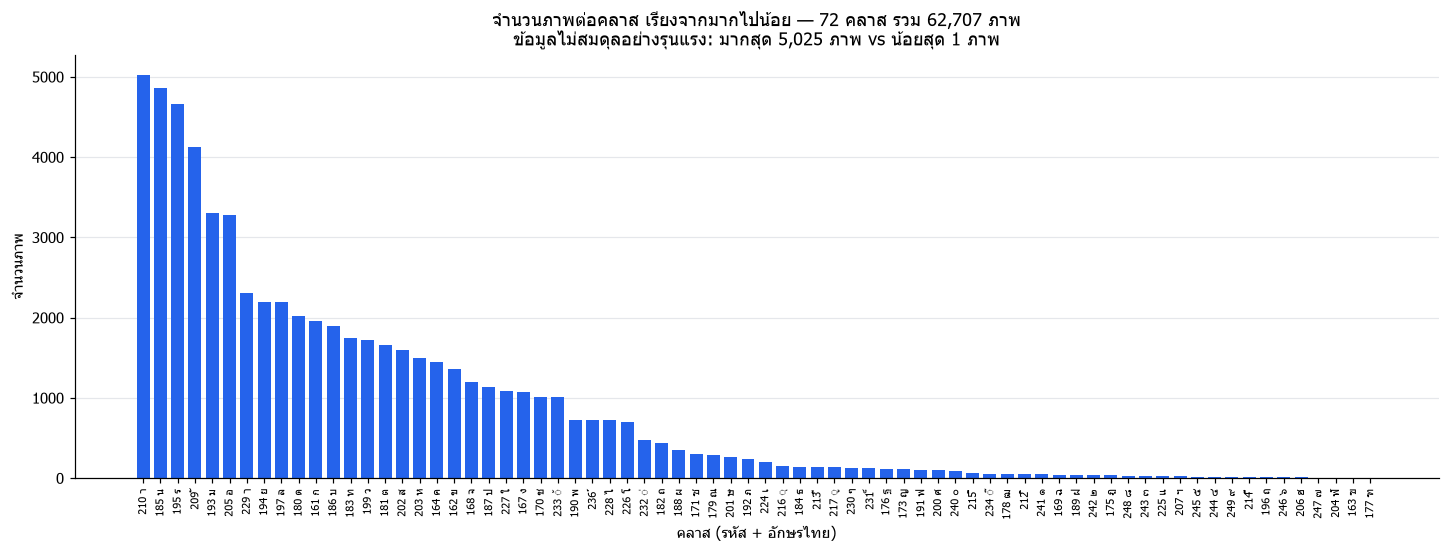

In [4]:
# ----- กราฟจำนวนภาพต่อคลาส เรียงจากมากไปน้อย -----
items = sorted(counts.items(), key=lambda kv: kv[1], reverse=True)
names = [thai_label(c) for c, _ in items]
values = [v for _, v in items]

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(range(len(values)), values, color=BLUE, width=0.75)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=7)
ax.set_xlabel("คลาส (รหัส + อักษรไทย)")
ax.set_ylabel("จำนวนภาพ")
ax.set_title(
    f"จำนวนภาพต่อคลาส เรียงจากมากไปน้อย — {len(values)} คลาส รวม {sum(values):,} ภาพ\n"
    f"ข้อมูลไม่สมดุลอย่างรุนแรง: มากสุด {max(values):,} ภาพ vs น้อยสุด {min(values):,} ภาพ"
)
tidy(ax)
plt.show()

In [5]:
# ----- 10 คลาสที่มีภาพมากสุด และ 10 คลาสที่น้อยสุด -----
top10 = pd.DataFrame(
    [{"คลาส": thai_label(c), "จำนวนภาพ": n} for c, n in items[:10]],
    index=range(1, 11),
)
bottom10 = pd.DataFrame(
    [{"คลาส": thai_label(c), "จำนวนภาพ": n} for c, n in items[-10:]],
    index=range(len(items) - 9, len(items) + 1),
)
print("10 คลาสที่มีภาพมากที่สุด" + " " * 18 + "10 คลาสที่มีภาพน้อยที่สุด")
print(pd.concat([top10.reset_index(drop=True), bottom10.reset_index(drop=True)], axis=1).to_string(index=False))

10 คลาสที่มีภาพมากที่สุด                  10 คลาสที่มีภาพน้อยที่สุด
 คลาส  จำนวนภาพ  คลาส  จำนวนภาพ
210 า      5025 244 ๔        16
185 น      4863 249 ๙        14
195 ร      4663 214 ึ        14
209 ั      4120 196 ฤ        13
193 ม      3306 246 ๖        12
205 อ      3272 206 ฮ        10
229 ๅ      2310 247 ๗         4
194 ย      2197 204 ฬ         3
197 ล      2187 163 ฃ         1
180 ด      2025 177 ฑ         1


### 1.1 การแบ่งข้อมูล: กันชุด test 5% ออกก่อนเป็นอย่างแรก

ลำดับการแบ่งมีความสำคัญ เพื่อรับประกันว่าชุด test ไม่เคยถูกโมเดลเห็น

1. ตัด **test 5%** ออกจากข้อมูลทั้งก้อนก่อน แบบ stratified (แบ่งภายในแต่ละคลาส)
2. ส่วนที่เหลือ 95% แบ่งเป็น **train 80% / validation 20%** แบบ stratified เช่นกัน
3. การ augment ทำกับแถวที่ `split == "train"` **เท่านั้น** (มี `assert` กำกับในโค้ด)

ทุกขั้นล็อกด้วย `SEED = 42` จึงแบ่งได้เหมือนเดิมทุกครั้งที่รัน

**ทำไมไม่ใช้ `sklearn.train_test_split(stratify=...)`**: ฟังก์ชันนั้นจะ error ทันที
ถ้าคลาสใดมีสมาชิกน้อยกว่าจำนวน split ที่ขอ ชุดข้อมูลนี้มีคลาสที่มีภาพเพียง 1 ภาพ
(`163 ฃ`, `177 ฑ`) และ 2 ภาพ (`204 ฬ`) จริง จึงต้องเขียนกฎรองรับคลาสเล็กเอง:

| จำนวนภาพในคลาส | test | val | train |
|---|---|---|---|
| ≥ 3 ภาพ | `round(n × 5%)` อย่างน้อย 1 | `round(เหลือ × 20%)` อย่างน้อย 1 | ที่เหลือ |
| 2 ภาพ | 0 | 1 | 1 |
| 1 ภาพ | 0 | 0 | 1 |

In [6]:
split_tbl = read_csv("01_split_per_class.csv", dtype={"class_id": str}).set_index("class_id")
totals = split_tbl[["train", "val", "test"]].sum()
grand = int(totals.sum())

summary = pd.DataFrame(
    {
        "จำนวนภาพ": [f"{int(totals[s]):,}" for s in ("train", "val", "test")],
        "สัดส่วน": [f"{totals[s] / grand:.1%}" for s in ("train", "val", "test")],
        "ใช้ทำอะไร": [
            "เทรนโมเดล (และเป็นชุดเดียวที่ถูก augment)",
            "วัดผลทุก epoch + เลือก best checkpoint",
            "กันไว้วัดผลสุดท้าย ไม่เคยถูกเทรนหรือ augment",
        ],
    },
    index=["train", "val", "test"],
)
print(summary.to_string())
print(f"\nรวม {grand:,} ภาพ")

no_test = split_tbl.index[split_tbl["test"] == 0].tolist()
if no_test:
    print(
        f"\nข้อจำกัดที่ต้องระบุ: {len(no_test)} คลาสไม่มีภาพในชุด test เลย "
        f"({', '.join(thai_label(c) for c in no_test)})"
    )
    print("เพราะทั้งคลาสมีภาพน้อยเกินกว่าจะแบ่งสามทางได้ — ผลบนชุด test จึงวัดได้ "
          f"{72 - len(no_test)} คลาสจาก 72 คลาส")

      จำนวนภาพ สัดส่วน                                     ใช้ทำอะไร
train   47,658   76.0%     เทรนโมเดล (และเป็นชุดเดียวที่ถูก augment)
val     11,913   19.0%        วัดผลทุก epoch + เลือก best checkpoint
test     3,136    5.0%  กันไว้วัดผลสุดท้าย ไม่เคยถูกเทรนหรือ augment

รวม 62,707 ภาพ

ข้อจำกัดที่ต้องระบุ: 2 คลาสไม่มีภาพในชุด test เลย (163 ฃ, 177 ฑ)
เพราะทั้งคลาสมีภาพน้อยเกินกว่าจะแบ่งสามทางได้ — ผลบนชุด test จึงวัดได้ 70 คลาสจาก 72 คลาส


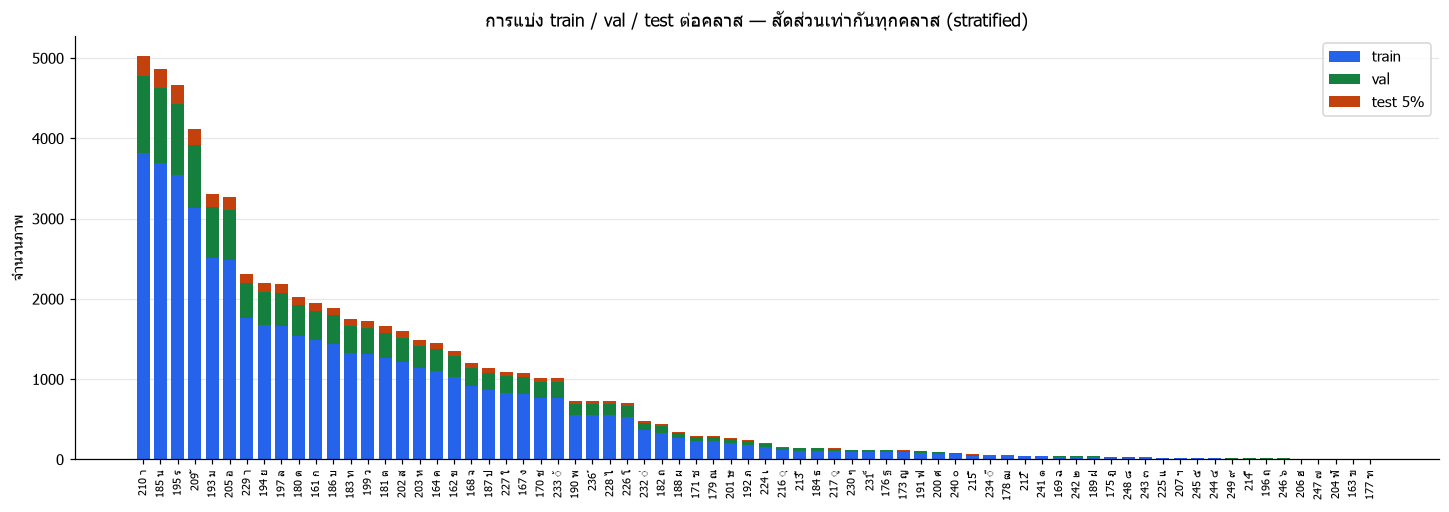

In [7]:
# ----- กราฟแท่งซ้อน: การแบ่ง train/val/test ต่อคลาส (ยืนยันว่า stratify ได้จริง) -----
df = split_tbl.sort_values("total", ascending=False)
x = np.arange(len(df))

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x, df["train"], color=BLUE, width=0.75, label="train")
ax.bar(x, df["val"], bottom=df["train"], color=GREEN, width=0.75, label="val")
ax.bar(x, df["test"], bottom=df["train"] + df["val"], color=RED, width=0.75, label="test 5%")
ax.set_xticks(x)
ax.set_xticklabels([thai_label(c) for c in df.index], rotation=90, fontsize=7)
ax.set_ylabel("จำนวนภาพ")
ax.set_title("การแบ่ง train / val / test ต่อคลาส — สัดส่วนเท่ากันทุกคลาส (stratified)")
ax.legend(frameon=True)
tidy(ax)
plt.show()

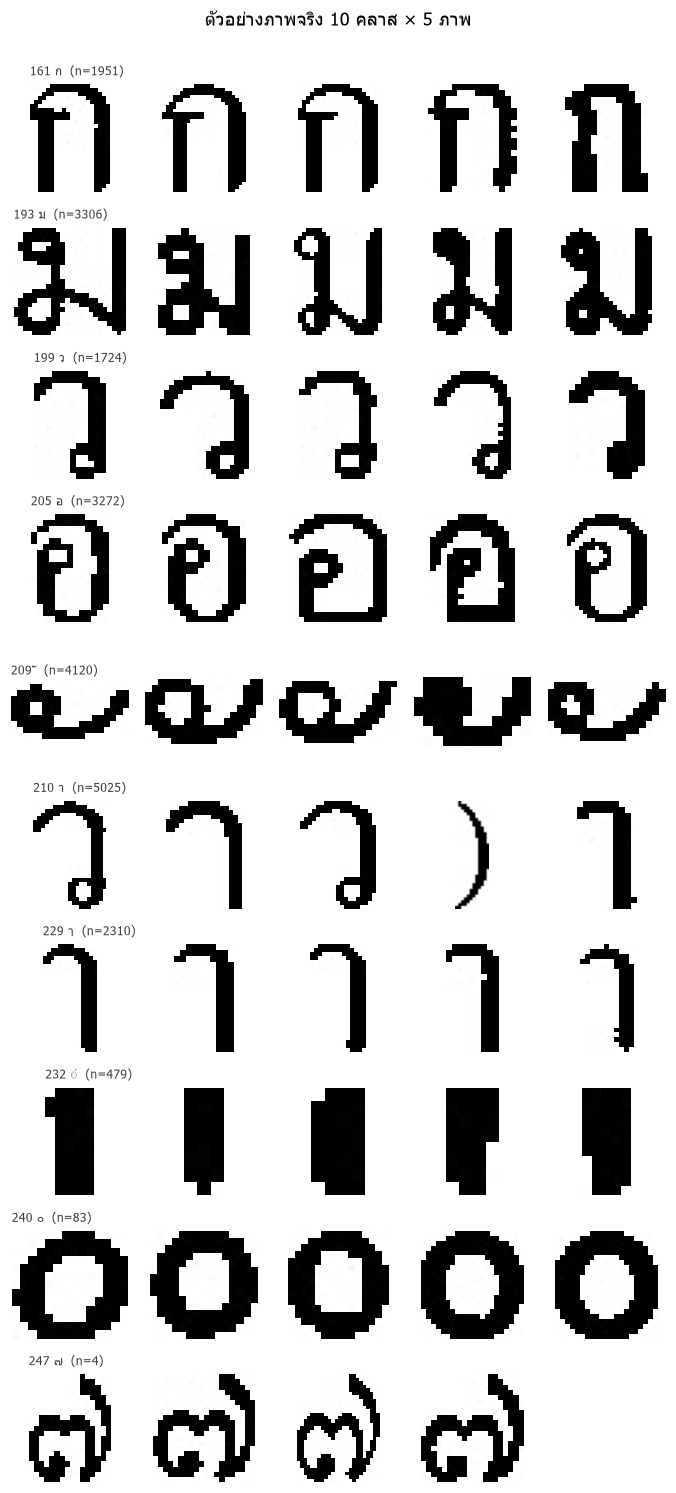

ขนาดภาพต้นฉบับ (สุ่ม 364 ภาพ): กว้าง 3–24 px, สูง 6–31 px
ภาพเล็กมากและไม่เป็นสี่เหลี่ยมจัตุรัส จึงต้อง resize เป็น 224×224 ก่อนเข้า ResNet50


In [8]:
# ----- ตัวอย่างภาพจริงจากชุดข้อมูล (ต้องมีโฟลเดอร์ dataset) -----
if not HAS_DATASET:
    print("ข้ามเซลล์นี้: ไม่พบโฟลเดอร์ภาพต้นฉบับ")
    print("ภาพตัวอย่างครบทั้ง 72 คลาสดูได้จากไฟล์ outputs/figures/01_sample_images.png")
else:
    from PIL import Image

    rng = np.random.RandomState(42)
    show_classes = ["161", "193", "199", "205", "209", "210", "229", "232", "240", "247"]
    n_per_class = 5

    fig, axes = plt.subplots(len(show_classes), n_per_class,
                             figsize=(n_per_class * 1.25, len(show_classes) * 1.35))
    for r, cid in enumerate(show_classes):
        files = sorted((DATA_ROOT / cid).glob("*.jpg"))
        picks = rng.choice(files, size=min(n_per_class, len(files)), replace=False)
        for c in range(n_per_class):
            ax = axes[r, c]
            ax.axis("off")
            if c < len(picks):
                with Image.open(picks[c]) as im:
                    ax.imshow(im.convert("RGB"))
            if c == 0:
                ax.set_title(f"{thai_label(cid)}  (n={len(files)})", fontsize=8, loc="left", color="#404040")
    fig.suptitle("ตัวอย่างภาพจริง 10 คลาส × 5 ภาพ", y=1.002, fontsize=12)
    plt.tight_layout()
    plt.show()

    # ขนาดภาพต้นฉบับ
    sizes = []
    for cid in show_classes:
        for f in sorted((DATA_ROOT / cid).glob("*.jpg"))[:40]:
            with Image.open(f) as im:
                sizes.append(im.size)
    w = [s[0] for s in sizes]
    h = [s[1] for s in sizes]
    print(f"ขนาดภาพต้นฉบับ (สุ่ม {len(sizes)} ภาพ): "
          f"กว้าง {min(w)}–{max(w)} px, สูง {min(h)}–{max(h)} px")
    print("ภาพเล็กมากและไม่เป็นสี่เหลี่ยมจัตุรัส จึงต้อง resize เป็น 224×224 ก่อนเข้า ResNet50")

<a id="2"></a>
## 2. Baseline เพื่อหา "คลาสที่ทายผิดบ่อย"

แนวคิดของ **error-driven augmentation** คือไม่ควรเดาว่าคลาสไหนยาก แต่ให้ข้อมูลบอก
จึงเทรนโมเดล baseline ขึ้นมาก่อน 3 epochs บนข้อมูล train ที่**ยังไม่ augment**
เพื่อดูว่าโมเดลทำคลาสไหนพลาด แล้วนำรายชื่อคลาสนั้นไปกำหนดความเข้มของการ augment

เกณฑ์การคัด (union ของสองกฎ) คิดจาก **per-class F1** บน validation

| กฎ | เหตุผล |
|---|---|
| F1 < ค่าเฉลี่ย − 1 SD | จับคลาสที่หลุดจากกลุ่มอย่างมีนัย |
| F1 อยู่ใน 20% ล่างสุด | รับประกันว่าจะได้คลาสที่แย่สุดมาจำนวนหนึ่งเสมอ แม้การกระจายจะแคบ |
| คลาสที่ไม่มีภาพใน validation | ข้อมูลน้อยเกินกว่าจะวัดได้ ถือเป็นคลาสที่ต้องช่วยโดยปริยาย |

**ทำไมใช้ F1 ไม่ใช่ recall**: recall อย่างเดียวมองไม่เห็นคลาสที่โมเดล "ทายเกิน"
(เดาคลาสนี้พร่ำเพรื่อจน precision ต่ำ) ซึ่งก็เป็นความสับสนที่ต้องแก้เหมือนกัน
F1 รวมทั้งสองด้านไว้ในตัวเดียว

In [9]:
base_metrics = read_json("02_baseline_metrics.json")
weak_info = read_json("02_weak_classes.json")
base_per_class = read_csv("02_baseline_per_class.csv", dtype={"class_id": str})

print(f"Baseline ResNet50 ({base_metrics['epochs']} epochs, ไม่ augment) บน validation "
      f"{base_metrics['n_val_images']:,} ภาพ")
print("-" * 72)
print(f"Accuracy          = {base_metrics['accuracy']:.4f}")
print(f"Macro F1          = {base_metrics['macro_f1']:.4f}")
print(f"Balanced accuracy = {base_metrics['balanced_accuracy']:.4f}")
print(f"Weighted F1       = {base_metrics['weighted_f1']:.4f}")
print()
print("สังเกตช่องว่างระหว่าง accuracy (0.98) กับ macro F1 (0.93): accuracy ถูกคลาสใหญ่")
print("ครอบงำจนดูดีเกินจริง ขณะที่ macro F1 เปิดให้เห็นว่ายังมีคลาสที่โมเดลทำได้แย่")

Baseline ResNet50 (3 epochs, ไม่ augment) บน validation 11,913 ภาพ
------------------------------------------------------------------------
Accuracy          = 0.9846
Macro F1          = 0.9273
Balanced accuracy = 0.9541
Weighted F1       = 0.9846

สังเกตช่องว่างระหว่าง accuracy (0.98) กับ macro F1 (0.93): accuracy ถูกคลาสใหญ่
ครอบงำจนดูดีเกินจริง ขณะที่ macro F1 เปิดให้เห็นว่ายังมีคลาสที่โมเดลทำได้แย่


In [10]:
print(f"เกณฑ์คัดคลาสอ่อนแอ (metric = {weak_info['metric']}, rule = {weak_info['rule']})")
print("-" * 72)
print(f"ค่าเฉลี่ย F1 ของทุกคลาส = {weak_info['mean_metric']:.4f}")
print(f"ส่วนเบี่ยงเบนมาตรฐาน    = {weak_info['sd_metric']:.4f}")
print(f"เกณฑ์ mean − 1SD        = {weak_info['threshold_mean_minus_1sd']:.4f}  "
      f"→ เข้าเกณฑ์ {weak_info['n_by_mean_sd']} คลาส")
print(f"เกณฑ์ bottom 20%        = {weak_info['threshold_bottom20']:.4f}  "
      f"→ เข้าเกณฑ์ {weak_info['n_by_bottom20']} คลาส")
print(f"คลาสที่ไม่มีภาพใน val    → บังคับเข้าเกณฑ์ {weak_info['n_unmeasured_forced_in']} คลาส")
print()
print(f"รวมเป็น {weak_info['n_weak_total']} คลาสที่จะได้ augmentation แบบเข้มข้น:")
print("  " + "  ".join(weak_info["weak_classes_labeled"]))

เกณฑ์คัดคลาสอ่อนแอ (metric = f1-score, rule = both)
------------------------------------------------------------------------
ค่าเฉลี่ย F1 ของทุกคลาส = 0.9538
ส่วนเบี่ยงเบนมาตรฐาน    = 0.1674
เกณฑ์ mean − 1SD        = 0.7864  → เข้าเกณฑ์ 3 คลาส
เกณฑ์ bottom 20%        = 0.9728  → เข้าเกณฑ์ 14 คลาส
คลาสที่ไม่มีภาพใน val    → บังคับเข้าเกณฑ์ 2 คลาส

รวมเป็น 16 คลาสที่จะได้ augmentation แบบเข้มข้น:
  163 ฃ  169 ฉ  170 ช  171 ซ  177 ฑ  199 ว  200 ศ  204 ฬ  210 า  213 ี  215 ื  217 ◌ู  229 ๅ  231 ็  247 ๗  248 ๘


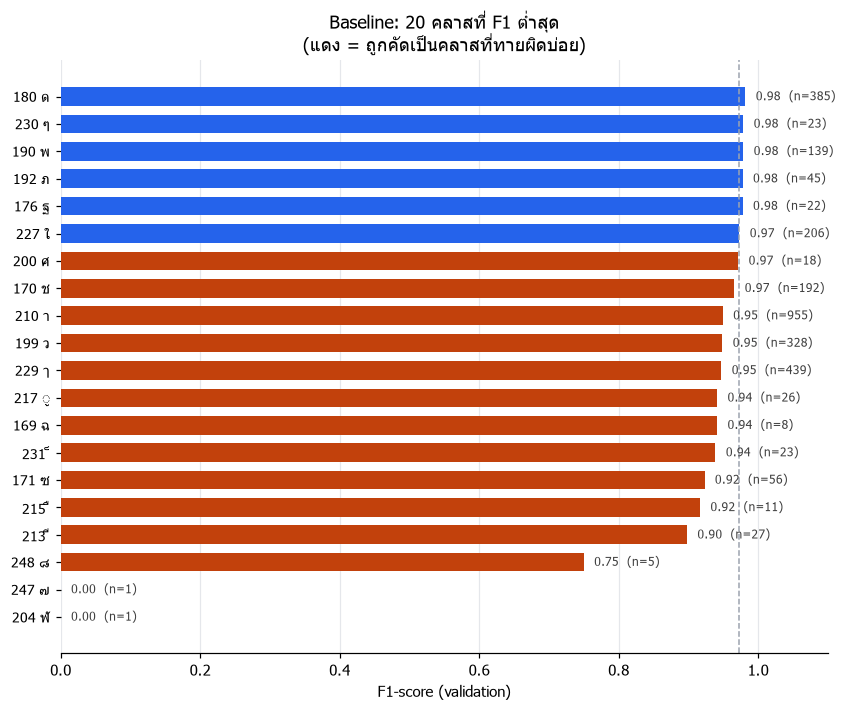

จำนวน support กำกับท้ายแท่งไว้เพราะ F1 ต่ำที่ n=5 กับ F1 ต่ำที่ n=500
เป็นปัญหาคนละแบบกันโดยสิ้นเชิง


In [11]:
# ----- F1 รายคลาสของ baseline: 20 คลาสที่ต่ำสุด -----
measured = base_per_class[base_per_class["support"] > 0].copy()
worst = measured.nsmallest(20, "f1-score").sort_values("f1-score")
weak_set = set(weak_info["weak_classes"])
colors = [RED if c in weak_set else BLUE for c in worst["class_id"]]

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(worst))
ax.barh(y, worst["f1-score"], color=colors, height=0.68)
ax.set_yticks(y)
ax.set_yticklabels(worst["label"], fontsize=9)
ax.set_xlim(0, 1.1)
ax.set_xlabel("F1-score (validation)")
ax.set_title("Baseline: 20 คลาสที่ F1 ต่ำสุด\n(แดง = ถูกคัดเป็นคลาสที่ทายผิดบ่อย)")
for yi, (f1, sup) in enumerate(zip(worst["f1-score"], worst["support"])):
    ax.text(f1 + 0.015, yi, f"{f1:.2f}  (n={int(sup)})", va="center", fontsize=8, color="#404040")
ax.axvline(weak_info["threshold_bottom20"], color=GREY, linestyle="--", linewidth=1)
tidy(ax, grid_axis="x")
ax.spines["left"].set_visible(False)
plt.show()

print("จำนวน support กำกับท้ายแท่งไว้เพราะ F1 ต่ำที่ n=5 กับ F1 ต่ำที่ n=500")
print("เป็นปัญหาคนละแบบกันโดยสิ้นเชิง")

<a id="3"></a>
## 3. Error-driven + Balanced Data Augmentation

เทคนิคนี้รวมสองแนวคิดเข้าด้วยกัน

**Balanced**: ทุกคลาสถูกเติมภาพจนมีจำนวนเท่ากับคลาสที่มีภาพมากที่สุด (3,819 ภาพในชุด train)
ทำให้ข้อมูลที่โมเดลเห็นในหนึ่ง epoch สมดุลกันพอดี ไม่มีคลาสใดได้เปรียบ

**Error-driven**: คลาสที่อยู่ในรายชื่อ "ทายผิดบ่อย" จากขั้นที่ 2 ใช้ transform ชุด
ที่เข้มข้นและหลากหลายกว่า เพื่อให้โมเดลได้เห็นความแปรผันของคลาสยาก ๆ มากขึ้น

### กฎเหล็ก: ห้าม Horizontal / Vertical Flip

ตัวอักษรไทยมีทิศทาง พลิกซ้าย-ขวาแล้วได้รูปที่เป็นอักขระอื่นหรือไม่มีในภาษา
เช่น **ก** พลิกแล้วมีรูปใกล้ **ฎ/ฏ** การ flip จึงเท่ากับป้อน label ผิดให้โมเดลโดยตรง
`augment.py` จึงไม่มี `RandomHorizontalFlip` หรือ `RandomVerticalFlip` เลย

In [12]:
aug_stats = read_json("03_augmentation_stats.json")

print("ผลของการ balance ชุด train")
print("-" * 72)
print(f"target ต่อคลาส        = {aug_stats['target_count']:,} ภาพ (= จำนวนภาพของคลาสที่มากสุด)")
print(f"train ก่อน augment    = {aug_stats['train_images_before']:,} ภาพ")
print(f"train หลัง augment    = {aug_stats['train_images_after']:,} ภาพ  "
      f"({aug_stats['growth_factor']} เท่า)")
print(f"ภาพที่สังเคราะห์เพิ่ม  = {aug_stats['synthesized_images']:,} ภาพ")
print(f"ความไม่สมดุล          = {aug_stats['imbalance_before']:,.0f} : 1  →  "
      f"{aug_stats['imbalance_after']:.0f} : 1")
print()
print("แยกตามชนิดการ augment:")
for kind, n in aug_stats["aug_kind_counts"].items():
    desc = {
        "original": "ภาพจริง ไม่แปลงอะไร",
        "normal": "augment ความเข้มปกติ",
        "intense": "augment เข้มข้น (คลาสที่ทายผิดบ่อย)",
        "light": "augment เบา ๆ",
    }.get(kind, "")
    print(f"  {kind:9s} {n:>8,} ภาพ   {desc}")

ผลของการ balance ชุด train
------------------------------------------------------------------------
target ต่อคลาส        = 3,819 ภาพ (= จำนวนภาพของคลาสที่มากสุด)
train ก่อน augment    = 47,658 ภาพ
train หลัง augment    = 274,968 ภาพ  (5.77 เท่า)
ภาพที่สังเคราะห์เพิ่ม  = 227,310 ภาพ
ความไม่สมดุล          = 3,819 : 1  →  1 : 1

แยกตามชนิดการ augment:
  normal     174,565 ภาพ   augment ความเข้มปกติ
  intense     52,745 ภาพ   augment เข้มข้น (คลาสที่ทายผิดบ่อย)
  original    47,658 ภาพ   ภาพจริง ไม่แปลงอะไร


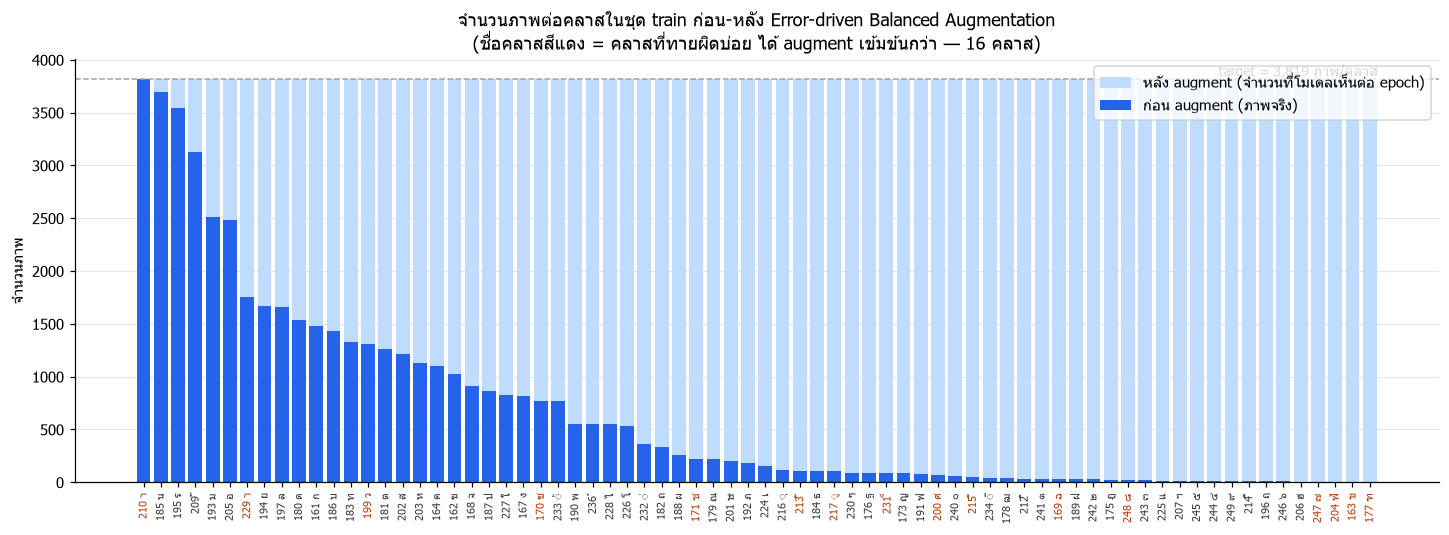

In [13]:
# ----- กราฟเทียบจำนวนภาพต่อคลาส ก่อน-หลัง augment -----
plan = read_csv("03_augmentation_plan.csv", dtype={"class_id": str}).set_index("class_id")
plan = plan.sort_values("before", ascending=False)
x = np.arange(len(plan))

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x, plan["total"], color="#BFDBFE", width=0.8, label="หลัง augment (จำนวนที่โมเดลเห็นต่อ epoch)")
ax.bar(x, plan["before"], color=BLUE, width=0.8, label="ก่อน augment (ภาพจริง)")
ax.axhline(aug_stats["target_count"], color=GREY, linestyle="--", linewidth=1)
ax.text(len(plan) - 0.5, aug_stats["target_count"], f" target = {aug_stats['target_count']:,} ภาพ/คลาส",
        va="bottom", ha="right", fontsize=9, color="#404040")
ax.set_xticks(x)
ax.set_xticklabels([thai_label(c) for c in plan.index], rotation=90, fontsize=7)
for tick, is_weak in zip(ax.get_xticklabels(), plan["is_weak_class"]):
    tick.set_color(RED if is_weak else "#404040")
ax.set_ylabel("จำนวนภาพ")
ax.set_title(
    "จำนวนภาพต่อคลาสในชุด train ก่อน-หลัง Error-driven Balanced Augmentation\n"
    f"(ชื่อคลาสสีแดง = คลาสที่ทายผิดบ่อย ได้ augment เข้มข้นกว่า — {int(plan['is_weak_class'].sum())} คลาส)"
)
ax.legend(frameon=True, loc="upper right")
tidy(ax)
plt.show()

### 3.1 Transform ที่ใช้ และเหตุผลของแต่ละตัว

| เทคนิค | ปกติ (normal) | เข้มข้น (intense) | จำลองความแปรผันอะไรของลายมือจริง |
|---|---|---|---|
| RandomRotation | ±10° | ±15° | การวางกระดาษเอียง / ลายมือเอียง |
| RandomAffine translate | 5% | 8% | ตำแหน่งตัวอักษรในกรอบไม่ตรงกลางเสมอ |
| RandomAffine scale | 0.88–1.05 | 0.80–1.05 | เขียนตัวใหญ่/เล็กไม่เท่ากัน |
| RandomAffine shear | 4° | 8° | ลายมือเอนแบบตัวเอียง |
| ElasticTransform | ไม่ใช้ | alpha 35, sigma 5 (p = 0.50) | เส้นบิดเบี้ยวตามธรรมชาติของมือ |
| Morphological dilate/erode | p = 0.25 | p = 0.45 | ปากกาหัวใหญ่/เล็ก กดหนัก/เบา |
| GaussianBlur | p = 0.20 | p = 0.30 | ภาพเบลอจากการสแกน |
| ColorJitter (brightness/contrast) | 0.12 | 0.20 | หมึกเข้ม/อ่อน กระดาษต่างเฉดกัน |
| Gaussian noise | std 0.015 (p = 0.30) | std 0.025 (p = 0.50) | noise ของกล้อง/สแกนเนอร์ |
| RandomErasing | ไม่ใช้ | p = 0.15 พื้นที่ 1–4% | หมึกขาดหาย กระดาษมีรอย |
| **Flip แนวนอน/แนวตั้ง** | **ห้ามใช้** | **ห้ามใช้** | — เปลี่ยนตัวอักษรเป็นตัวอื่น |

**รายละเอียดที่มีผลจริงต่อคุณภาพภาพ** (ปรับหลังจากเปิดภาพที่ augment ออกมาดู)

- ทุก transform เชิงเรขาคณิตเติมพื้นที่ว่างด้วย**สีขาว** ให้ตรงกับพื้นหลังของภาพจริง
  ถ้าเติมดำจะเกิดขอบดำปลอมที่โมเดลอาจเรียนรู้เป็น feature
- **เพดาน scale หยุดที่ 1.05** เพราะตัวอักษรกินพื้นที่เกือบเต็มเฟรมอยู่แล้ว
  การซูมเข้ามากกว่านี้ตัดเส้นหัวหรือหางตัวอักษรหาย ซึ่งอาจทำให้กลายเป็นตัวอักษรอื่น
  = ป้อน label ผิด (การซูมออกปลอดภัย เพราะได้ขอบขาวเพิ่มเหมือนเขียนตัวเล็กลง)
- **ColorJitter คุมไว้ที่ 0.20** ตอนแรกตั้ง 0.30 แล้วพบว่าพื้นหลังกลายเป็นเทากลางภาพ
  ซึ่งไม่เคยเกิดใน validation/test ที่พื้นหลังขาวเสมอ = เทรนบน distribution ที่ผิด
- **RandomErasing วางก่อน Normalize และเติมค่า 1.0 (ขาว)** เพื่อให้เป็น "หมึกหาย" จริง
  ถ้าวางหลัง Normalize ค่า 0 จะกลายเป็นสี่เหลี่ยมเทากลางภาพซึ่งไม่เหมือนอะไรบนกระดาษ

In [14]:
# แสดงโค้ดจริงของ transform ชุดเข้มข้น (อ่านจากไฟล์ torch_pipeline/augment.py)
import inspect

from torch_pipeline import augment as A

print(inspect.getsource(A.RandomMorphology))
print(inspect.getsource(A.build_intense_transform))

class RandomMorphology:
    """dilate/erode ของหมึก = ทำให้เส้นหนาขึ้น/บางลง

    ภาพเป็นหมึกเข้มบนพื้นขาว ดังนั้น
      MinFilter -> ค่าต่ำ (เข้ม) แพร่ออก = เส้นหนาขึ้น (dilate หมึก)
      MaxFilter -> ค่าสูง (ขาว) แพร่ออก = เส้นบางลง (erode หมึก)
    เลียนแบบการเขียนด้วยปากกาหัวใหญ่/เล็ก หรือกดหนัก/เบา ซึ่งเป็นความแปรผัน
    ที่พบมากที่สุดอย่างหนึ่งในลายมือจริง
    """

    def __init__(self, size: int = 3, p_thicken: float = 0.5):
        self.size = size
        self.p_thicken = p_thicken

    def __call__(self, img: Image.Image) -> Image.Image:
        if random.random() < self.p_thicken:
            return img.filter(ImageFilter.MinFilter(self.size))
        return img.filter(ImageFilter.MaxFilter(self.size))

def build_intense_transform(img_size: int = cfg.IMG_SIZE, pad_square: bool = cfg.PAD_TO_SQUARE):
    """เข้มข้น (error-driven): ±15 องศา, ElasticTransform จำลองลายมือบิดเบี้ยว,
    morphological บ่อยขึ้น, RandomErasing เบา ๆ จำลองหมึกขาดหาย

    RandomErasing วางไว้ก่อน Nor

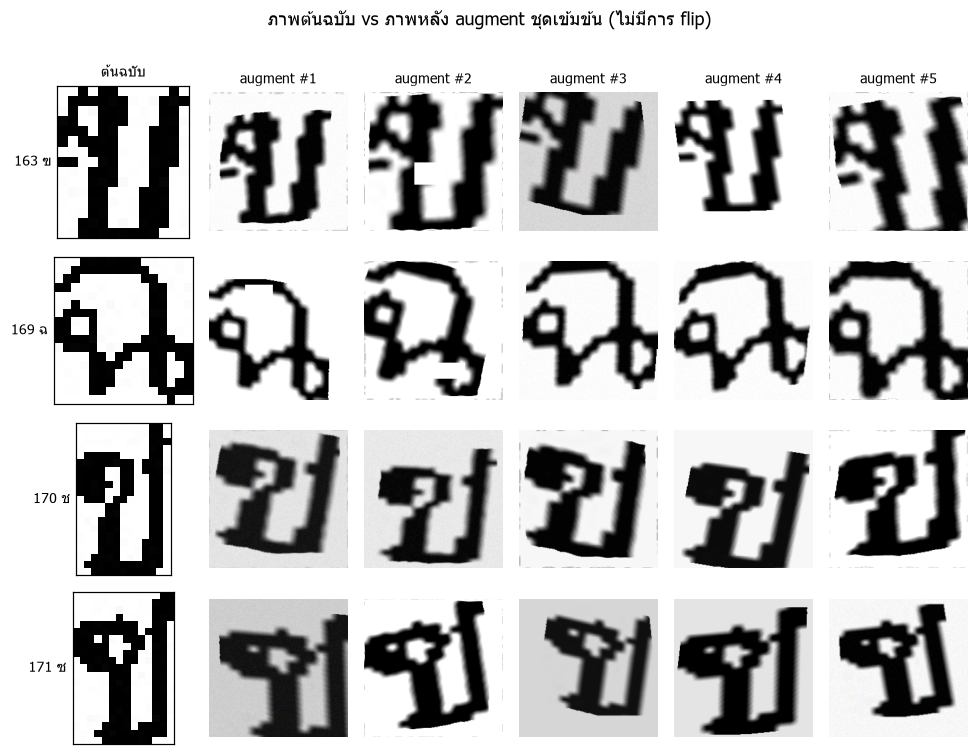

In [15]:
# ----- ตัวอย่างภาพจริง vs ภาพหลัง augment (ต้องมีโฟลเดอร์ dataset) -----
if not HAS_DATASET:
    print("ข้ามเซลล์นี้: ไม่พบโฟลเดอร์ภาพต้นฉบับ")
    print("ตัวอย่างดูได้จากไฟล์ outputs/figures/03_augmentation_examples.png")
else:
    from PIL import Image

    # เลือกคลาสที่อยู่ในรายชื่อ "ทายผิดบ่อย" เพราะเป็นกลุ่มที่ใช้ transform เข้มข้น
    demo = [c for c in weak_info["weak_classes"] if (DATA_ROOT / c).exists()][:4]
    n_variants = 5

    fig, axes = plt.subplots(len(demo), n_variants + 1,
                             figsize=((n_variants + 1) * 1.5, len(demo) * 1.7))
    for r, cid in enumerate(demo):
        src = sorted((DATA_ROOT / cid).glob("*.jpg"))[0]
        with Image.open(src) as im:
            axes[r, 0].imshow(im.convert("RGB"))
        axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
        axes[r, 0].set_ylabel(thai_label(cid), fontsize=9, rotation=0, ha="right", va="center")
        if r == 0:
            axes[r, 0].set_title("ต้นฉบับ", fontsize=9)
        for c in range(1, n_variants + 1):
            # augment_preview ใช้ seed เดียวกับที่ manifest ล็อกไว้ จึงได้ภาพแบบเดียว
            # กับที่โมเดลเห็นจริงตอนเทรน
            axes[r, c].imshow(A.augment_preview(str(src), "intense", seed=100 * r + c))
            axes[r, c].axis("off")
            if r == 0:
                axes[r, c].set_title(f"augment #{c}", fontsize=9)
    fig.suptitle("ภาพต้นฉบับ vs ภาพหลัง augment ชุดเข้มข้น (ไม่มีการ flip)", y=1.003, fontsize=12)
    plt.tight_layout()
    plt.show()

### 3.2 การเก็บชุดข้อมูลที่ augment แล้ว

การ balance ทุกคลาสถึง 3,819 ภาพได้ชุด train **274,968 ภาพต่อ epoch** ถ้าเขียนเป็น
ไฟล์ .jpg ขนาด 224×224 จะกินดิสก์ประมาณ 20 GB และเสียเวลาเขียน/อ่านฟรี ๆ

จึงเก็บเป็น **manifest** แทน: ตารางที่หนึ่งแถว = หนึ่งภาพที่โมเดลจะเห็น โดยเก็บว่า
*(ภาพต้นฉบับไหน, ความเข้มระดับไหน, seed อะไร)* แล้วแปลงภาพตอนโหลดใน `__getitem__`
ภายใน `torch.random.fork_rng()` ที่ตั้ง seed จาก manifest

ผลลัพธ์เทียบเท่ากับการมีไฟล์ภาพจริง 274,968 ไฟล์ ที่ **คงที่ทุก epoch และ
reproduce ได้ 100%** ต่างจากการ augment แบบสุ่มสดทุกครั้งที่โหลด และภาพต้นฉบับ
ถูกวนใช้เป็นต้นแบบแบบ round-robin ทุกภาพจึงถูกใช้ใกล้เคียงกัน ไม่ใช่สุ่มจนภาพ
บางใบถูกใช้ 10 ครั้งอีกใบ 0 ครั้ง

<a id="4"></a>
## 4. โครงสร้างโมเดลและการเทรน

In [16]:
import torch

from torch_pipeline import model as M

# pretrained=False เพื่อไม่ต้องดาวน์โหลด weight ตอนรัน notebook
# (ตอนเทรนจริงใช้ weights=ResNet50_Weights.IMAGENET1K_V2)
net = M.build_resnet50(num_classes=72, pretrained=False)
total, trainable = M.count_parameters(net)

print("ResNet50 — โครงสร้างและขนาดข้อมูลที่ไหลผ่านแต่ละชั้น")
print("=" * 72)
x = torch.zeros(1, 3, 224, 224)
print(f"{'input':<12} {tuple(x.shape[1:])}")
net.eval()
with torch.no_grad():
    for name, module in net.named_children():
        if name == "fc":
            x = torch.flatten(x, 1)
        x = module(x)
        kind = type(module).__name__
        print(f"{name:<12} {str(tuple(x.shape[1:])):<20} {kind}")
print("=" * 72)
print(f"พารามิเตอร์ทั้งหมด = {total:,} ตัว")
print(f"พารามิเตอร์ที่เทรน = {trainable:,} ตัว  ({trainable / total:.0%} = fine-tune ทั้งโมเดล)")

ResNet50 — โครงสร้างและขนาดข้อมูลที่ไหลผ่านแต่ละชั้น
input        (3, 224, 224)
conv1        (64, 112, 112)       Conv2d
bn1          (64, 112, 112)       BatchNorm2d
relu         (64, 112, 112)       ReLU
maxpool      (64, 56, 56)         MaxPool2d
layer1       (256, 56, 56)        Sequential
layer2       (512, 28, 28)        Sequential
layer3       (1024, 14, 14)       Sequential
layer4       (2048, 7, 7)         Sequential
avgpool      (2048, 1, 1)         AdaptiveAvgPool2d
fc           (72,)                Linear
พารามิเตอร์ทั้งหมด = 23,655,560 ตัว
พารามิเตอร์ที่เทรน = 23,655,560 ตัว  (100% = fine-tune ทั้งโมเดล)


### 4.1 ทำไม ResNet50 และทำไม fine-tune ทั้งโมเดล

**ResNet50** เป็น CNN ลึก 50 ชั้นที่สร้างจาก bottleneck block
(conv 1×1 → conv 3×3 → conv 1×1) ต่อกันเป็น 4 stage โดยแต่ละ block มี
**skip connection** บวกค่า input เข้ากับ output ทำให้ gradient ไหลข้ามชั้นได้
จึงเทรนโมเดลลึกระดับนี้ได้โดยไม่เจอปัญหา vanishing gradient

**การเปลี่ยนชั้นสุดท้าย**: ชั้น `fc` เดิมของ ImageNet มี 1,000 output (1,000 คลาสภาพถ่าย)
ถูกแทนด้วย `nn.Linear(2048, 72)` ที่สุ่มค่าเริ่มต้นใหม่

**ทำไม unfreeze ทุกชั้น ไม่ freeze backbone ไว้แล้วเทรนแค่ `fc`**: ImageNet เป็นภาพถ่าย
ธรรมชาติ (สัตว์ สิ่งของ ทิวทัศน์) ส่วนงานนี้เป็นลายเส้นขาว-ดำของตัวอักษร ฟีเจอร์ชั้น
กลาง-ปลายที่ ImageNet เรียนมา (texture ขนสัตว์ ลายผ้า สีของวัตถุ) แทบไม่ตรงกับงานนี้เลย
ถ้า freeze ไว้โมเดลจะติดเพดานเร็ว การ unfreeze ทั้งหมดด้วย learning rate ต่ำ (1e-4)
ทำให้ทุกชั้นปรับตัวเข้าหาลายเส้นได้ ขณะที่ยังได้ประโยชน์จาก edge/stroke detector
ในชั้นต้น ๆ ที่ pretrained มาแล้ว — การเทรนจากศูนย์บนภาพเล็ก ๆ 47,658 ภาพจะ
overfit ง่ายกว่ามาก

In [17]:
train_summary = read_json("04_training_summary.json")

config_table = pd.DataFrame(
    [
        ("น้ำหนักเริ่มต้น", "ResNet50_Weights.IMAGENET1K_V2 (pretrained บน ImageNet)"),
        ("กลยุทธ์ transfer learning", "fine-tune ทั้งโมเดล (unfreeze ทุกชั้น)"),
        ("ขนาดภาพเข้าโมเดล", "224 × 224 × 3 (resize bicubic จากภาพต้นฉบับ)"),
        ("Normalize", "ImageNet mean (0.485, 0.456, 0.406) / std (0.229, 0.224, 0.225)"),
        ("Loss function", f"CrossEntropyLoss (label_smoothing = {train_summary['label_smoothing']})"),
        ("Optimizer", f"{train_summary['optimizer']} (lr = {train_summary['lr']}, "
                      f"weight_decay = {train_summary['weight_decay']})"),
        ("Scheduler", f"{train_summary['scheduler']} (lr ลดแบบโคไซน์จนเกือบ 0)"),
        ("Batch size", str(train_summary["batch_size"])),
        ("จำนวน epoch", str(train_summary["epochs_run"])),
        ("ภาพต่อ epoch", f"{train_summary['train_images_per_epoch']:,} ภาพ (balance แล้ว)"),
        ("Mixed precision (AMP)", "เปิด (fp16 + GradScaler)"),
        ("เกณฑ์เลือก best checkpoint", f"{train_summary['best_metric']} บน validation"),
        ("Random seed", "42 (ล็อก random, numpy, torch, cuda)"),
    ],
    columns=["รายการ", "ค่าที่ใช้"],
)
print(config_table.to_string(index=False))

                    รายการ                                                       ค่าที่ใช้
           น้ำหนักเริ่มต้น         ResNet50_Weights.IMAGENET1K_V2 (pretrained บน ImageNet)
 กลยุทธ์ transfer learning                          fine-tune ทั้งโมเดล (unfreeze ทุกชั้น)
          ขนาดภาพเข้าโมเดล                    224 × 224 × 3 (resize bicubic จากภาพต้นฉบับ)
                 Normalize ImageNet mean (0.485, 0.456, 0.406) / std (0.229, 0.224, 0.225)
             Loss function                        CrossEntropyLoss (label_smoothing = 0.1)
                 Optimizer                        AdamW (lr = 0.0001, weight_decay = 0.01)
                 Scheduler                     CosineAnnealingLR (lr ลดแบบโคไซน์จนเกือบ 0)
                Batch size                                                              48
               จำนวน epoch                                                              10
              ภาพต่อ epoch                                      274,968 ภาพ (balance แล้ว)

### 4.2 เกณฑ์เลือก best checkpoint: Macro F1 ไม่ใช่ Accuracy

ข้อมูลชุดนี้ไม่สมดุลอย่างรุนแรง (5,025 : 1) ถ้าใช้ accuracy เป็นเกณฑ์เลือก checkpoint
โมเดลที่เก่งแต่คลาสใหญ่จะได้คะแนนสูงแม้คลาสเล็กจะพังทั้งคลาส เพราะคลาสใหญ่ไม่กี่คลาส
กินสัดส่วนข้อมูลไปเกือบครึ่ง

**Macro F1** เฉลี่ย F1 ของทุกคลาสด้วยน้ำหนักเท่ากัน คลาสที่มี 5 ภาพจึงมีความสำคัญ
เท่ากับคลาสที่มี 5,000 ภาพ — เป็นตัวเลขที่สะท้อนความสามารถจริงของโมเดลกับงานนี้

ในการเทรนครั้งนี้ทั้งสองเกณฑ์เลือก epoch ต่างกันจริง: **macro F1 เลือก epoch 8**
ขณะที่ accuracy จะเลือก epoch 10 (accuracy ยังนำอยู่เล็กน้อยที่ epoch สุดท้าย
แต่ macro F1 ตกลงแล้ว)

In [18]:
history = read_csv("04_training_history.csv")

show = history[["epoch", "train_loss", "train_acc", "train_macro_f1",
                "val_loss", "val_acc", "val_macro_f1"]].copy()
show.columns = ["epoch", "train loss", "train acc", "train F1", "val loss", "val acc", "val F1"]
best_ep = int(train_summary["best_epoch"])
print("ประวัติการเทรน 10 epochs   (★ = epoch ที่ถูกเลือกเป็น best checkpoint)")
print("-" * 78)
for _, r in show.iterrows():
    star = "★" if int(r["epoch"]) == best_ep else " "
    print(f"{star} {int(r['epoch']):>2}  "
          f"train: loss {r['train loss']:.4f}  acc {r['train acc']:.4f}  F1 {r['train F1']:.4f}   |   "
          f"val: loss {r['val loss']:.4f}  acc {r['val acc']:.4f}  F1 {r['val F1']:.4f}")
print("-" * 78)
print(f"เวลาเทรนรวม = {history['seconds'].sum() / 3600:.2f} ชั่วโมง "
      f"(เฉลี่ย {history['seconds'].mean() / 60:.1f} นาทีต่อ epoch)")

ประวัติการเทรน 10 epochs   (★ = epoch ที่ถูกเลือกเป็น best checkpoint)
------------------------------------------------------------------------------
   1  train: loss 0.8435  acc 0.9749  F1 0.9749   |   val: loss 0.8111  acc 0.9781  F1 0.9479
   2  train: loss 0.7650  acc 0.9941  F1 0.9941   |   val: loss 0.8109  acc 0.9782  F1 0.9449
   3  train: loss 0.7589  acc 0.9955  F1 0.9955   |   val: loss 0.7998  acc 0.9823  F1 0.9453
   4  train: loss 0.7545  acc 0.9964  F1 0.9964   |   val: loss 0.8050  acc 0.9794  F1 0.9560
   5  train: loss 0.7510  acc 0.9974  F1 0.9974   |   val: loss 0.7907  acc 0.9849  F1 0.9552
   6  train: loss 0.7484  acc 0.9981  F1 0.9981   |   val: loss 0.7940  acc 0.9822  F1 0.9552
   7  train: loss 0.7463  acc 0.9988  F1 0.9988   |   val: loss 0.7909  acc 0.9858  F1 0.9580
★  8  train: loss 0.7448  acc 0.9994  F1 0.9994   |   val: loss 0.7919  acc 0.9859  F1 0.9584
   9  train: loss 0.7440  acc 0.9996  F1 0.9996   |   val: loss 0.7942  acc 0.9856  F1 0.9561
  10

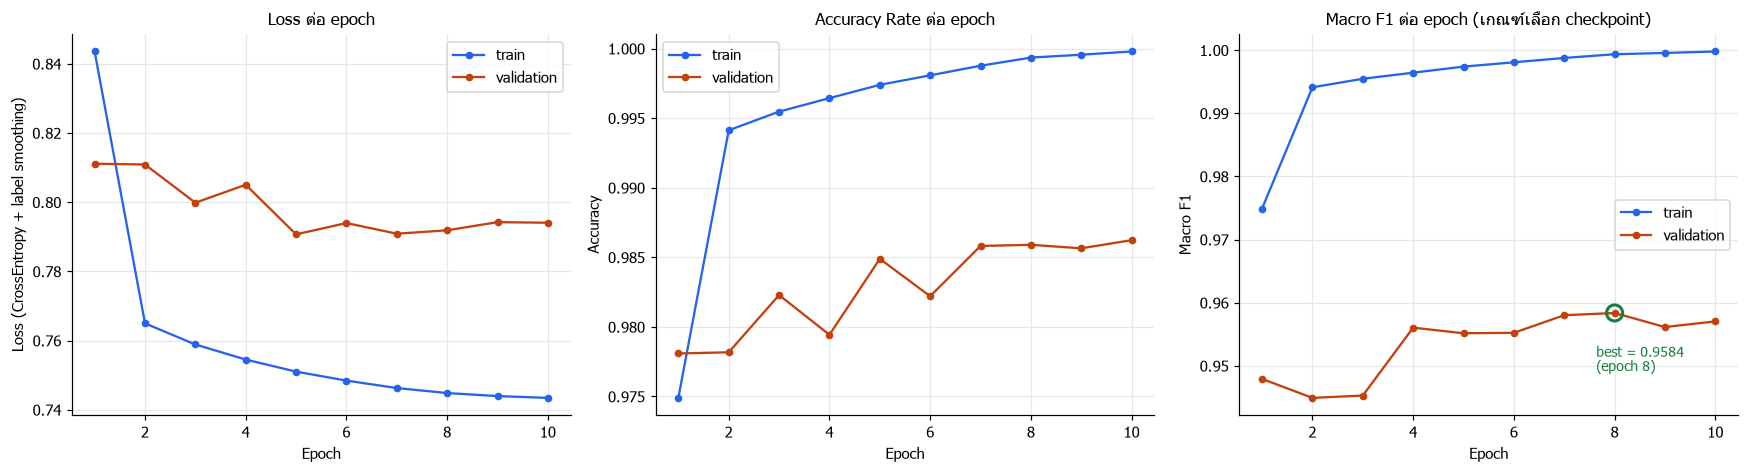

อ่านกราฟ: train F1 ไปถึง 0.9998 ขณะที่ val F1 อยู่ราว 0.955–0.958 ช่องว่างนี้
คือ overfitting ที่เหลืออยู่ — โมเดลจำชุด train ได้เกือบหมดแล้ว ส่วน val ขยับ
ช้าลงตาม learning rate ที่ลดแบบโคไซน์


In [19]:
# ----- Learning curves: Loss / Accuracy Rate / Macro F1 -----
ep = history["epoch"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

panels = [
    ("train_loss", "val_loss", "Loss ต่อ epoch", "Loss (CrossEntropy + label smoothing)", False),
    ("train_acc", "val_acc", "Accuracy Rate ต่อ epoch", "Accuracy", False),
    ("train_macro_f1", "val_macro_f1", "Macro F1 ต่อ epoch (เกณฑ์เลือก checkpoint)", "Macro F1", True),
]
for ax, (tr_key, val_key, title, ylabel, mark) in zip(axes, panels):
    ax.plot(ep, history[tr_key], color=BLUE, marker="o", markersize=4, label="train")
    ax.plot(ep, history[val_key], color=RED, marker="o", markersize=4, label="validation")
    if mark:
        row = history.loc[history[val_key].idxmax()]
        ax.scatter([row["epoch"]], [row[val_key]], s=110, facecolor="none",
                   edgecolor=GREEN, linewidth=2, zorder=5)
        ax.annotate(f"best = {row[val_key]:.4f}\n(epoch {int(row['epoch'])})",
                    (row["epoch"], row[val_key]), textcoords="offset points",
                    xytext=(-12, -38), fontsize=9, color=GREEN)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.legend(frameon=True)
    tidy(ax, grid_axis="both")
plt.tight_layout()
plt.show()

print("อ่านกราฟ: train F1 ไปถึง 0.9998 ขณะที่ val F1 อยู่ราว 0.955–0.958 ช่องว่างนี้")
print("คือ overfitting ที่เหลืออยู่ — โมเดลจำชุด train ได้เกือบหมดแล้ว ส่วน val ขยับ")
print("ช้าลงตาม learning rate ที่ลดแบบโคไซน์")

<a id="5"></a>
## 5. ผลบน Validation

In [20]:
val_metrics = read_json("05_metrics_val.json")
val_per_class = read_csv("05_classification_report_val.csv", dtype={"class_id": str})

print(f"โมเดลสุดท้าย (best checkpoint = epoch {best_ep}) บน validation "
      f"{val_metrics['n_images']:,} ภาพ")
print("=" * 72)
print(f"Accuracy          = {val_metrics['accuracy']:.4f}")
print(f"Macro F1          = {val_metrics['macro_f1']:.4f}")
print(f"Weighted F1       = {val_metrics['weighted_f1']:.4f}")
print(f"Balanced accuracy = {val_metrics['balanced_accuracy']:.4f}")
print(f"Top-5 accuracy    = {val_metrics['top5_accuracy']:.4f}")
print("=" * 72)
print(f"คลาสที่วัดผลได้ = {val_metrics['n_classes_measured']} / {val_metrics['n_classes']} คลาส")
print(f"คลาสที่ F1 < {val_metrics['weak_threshold']:.2f} = {val_metrics['classes_below_threshold']} คลาส")

โมเดลสุดท้าย (best checkpoint = epoch 8) บน validation 11,913 ภาพ
Accuracy          = 0.9859
Macro F1          = 0.9584
Weighted F1       = 0.9859
Balanced accuracy = 0.9860
Top-5 accuracy    = 0.9985
คลาสที่วัดผลได้ = 70 / 72 คลาส
คลาสที่ F1 < 0.80 = 0 คลาส


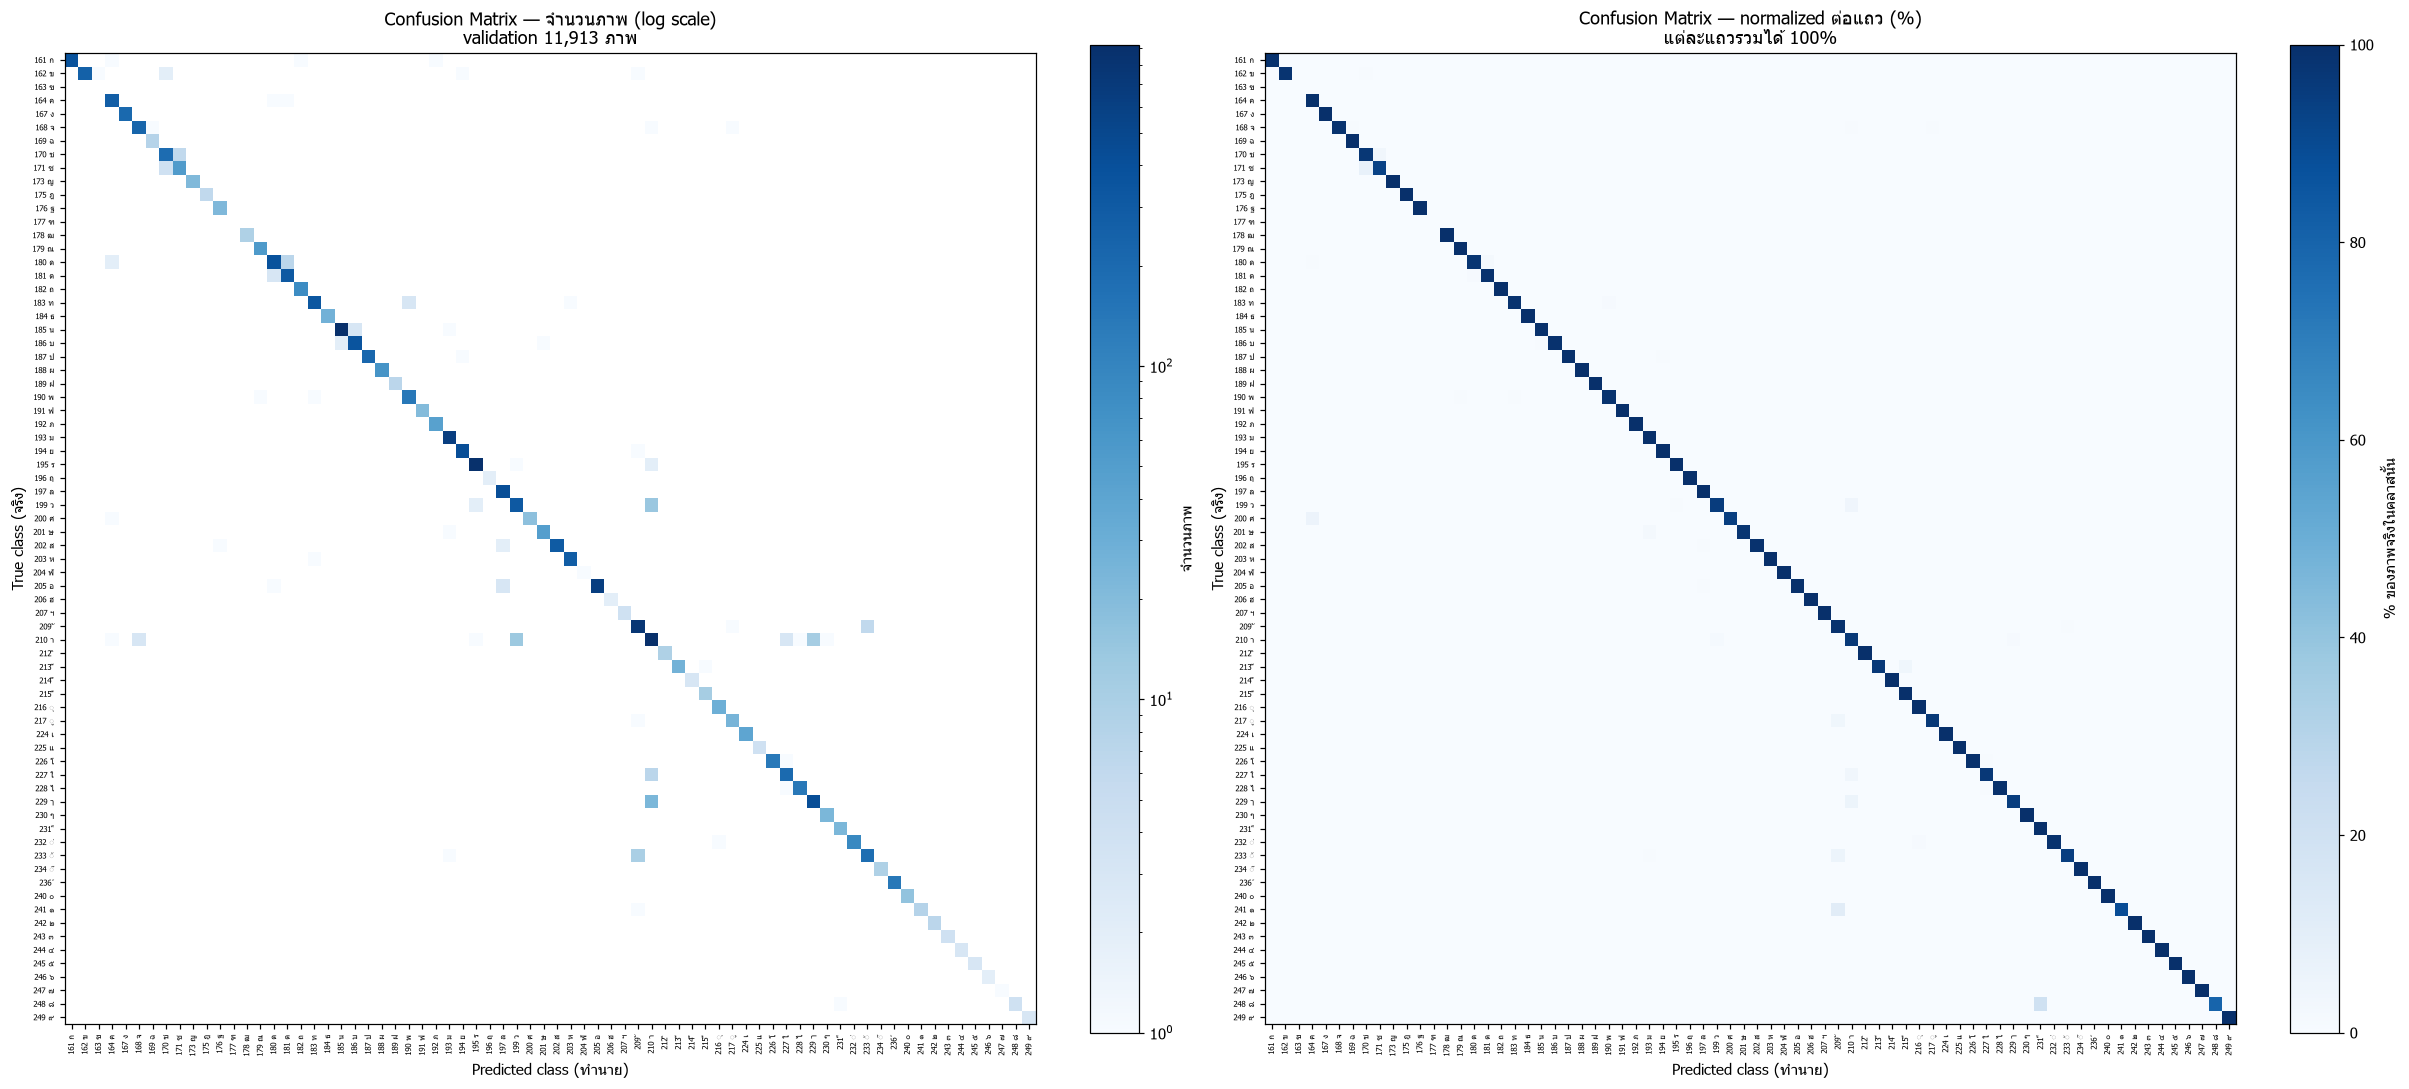

เส้นทแยงมุมเข้มต่อเนื่องทั้งเส้น = โมเดลทายถูกเป็นส่วนใหญ่ในทุกคลาส
ไฟล์ความละเอียดสูง (24×24 นิ้ว dpi 300) อยู่ที่ outputs/figures/


In [21]:
# ----- Confusion Matrix 72 × 72 -----
from matplotlib.colors import LogNorm

cm_df = read_csv("05_confusion_matrix_val.csv", index_col=0)
cm = cm_df.to_numpy()
ticks = list(cm_df.index)

fig, axes = plt.subplots(1, 2, figsize=(22, 10.5))

# ซ้าย: จำนวนภาพ (log scale) - บนข้อมูลไม่สมดุล ค่าบนเส้นทแยงมุมสูงกว่านอกเส้น
# ทแยง 2-3 order of magnitude ถ้าใช้สเกลเชิงเส้นจุดที่สับสนจะจางหายไปหมด
masked = np.ma.masked_where(cm == 0, cm)
im0 = axes[0].imshow(masked, cmap="Blues", norm=LogNorm(vmin=1, vmax=cm.max()))
axes[0].set_title(f"Confusion Matrix — จำนวนภาพ (log scale)\nvalidation {cm.sum():,} ภาพ")
fig.colorbar(im0, ax=axes[0], fraction=0.046, label="จำนวนภาพ")

# ขวา: normalized ต่อแถว (%) - เทียบคลาสใหญ่กับคลาสเล็กได้อย่างเป็นธรรม
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm * 100.0, row_sums, out=np.zeros(cm.shape, dtype=float), where=row_sums > 0)
im1 = axes[1].imshow(cm_norm, cmap="Blues", vmin=0, vmax=100)
axes[1].set_title("Confusion Matrix — normalized ต่อแถว (%)\nแต่ละแถวรวมได้ 100%")
fig.colorbar(im1, ax=axes[1], fraction=0.046, label="% ของภาพจริงในคลาสนั้น")

for ax in axes:
    ax.set_xticks(range(len(ticks)))
    ax.set_yticks(range(len(ticks)))
    ax.set_xticklabels(ticks, rotation=90, fontsize=5)
    ax.set_yticklabels(ticks, fontsize=5)
    ax.set_xlabel("Predicted class (ทำนาย)")
    ax.set_ylabel("True class (จริง)")
plt.tight_layout()
plt.show()

print("เส้นทแยงมุมเข้มต่อเนื่องทั้งเส้น = โมเดลทายถูกเป็นส่วนใหญ่ในทุกคลาส")
print("ไฟล์ความละเอียดสูง (24×24 นิ้ว dpi 300) อยู่ที่ outputs/figures/")

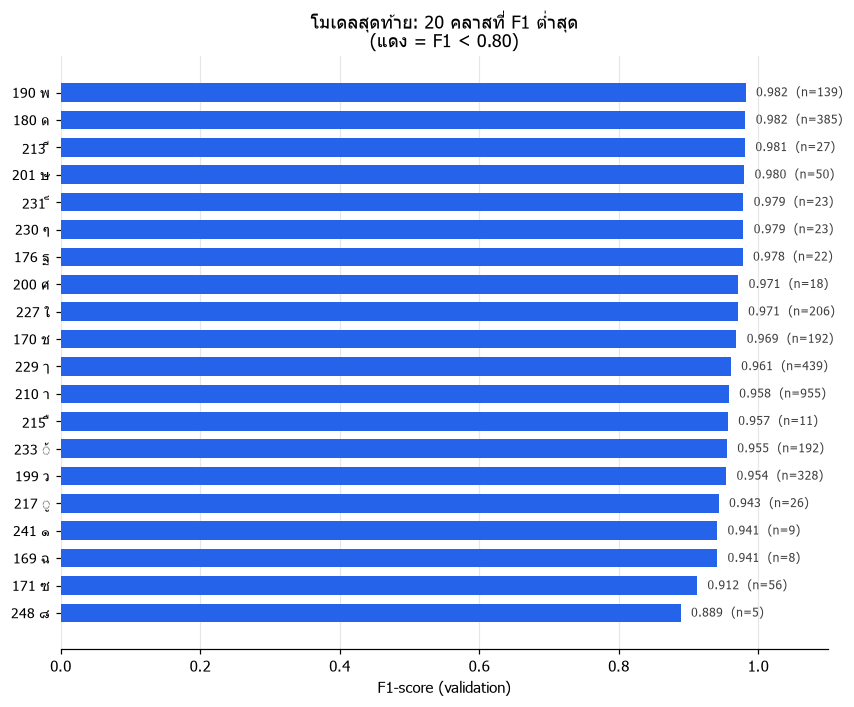

classification report เต็มทั้ง 72 คลาสอยู่ที่ outputs/reports/05_classification_report_val.csv


In [22]:
# ----- F1 รายคลาส: 20 คลาสที่ต่ำสุดของโมเดลสุดท้าย -----
val_measured = val_per_class[val_per_class["support"] > 0]
worst_val = val_measured.nsmallest(20, "f1-score").sort_values("f1-score")

fig, ax = plt.subplots(figsize=(9, 7))
y = np.arange(len(worst_val))
colors = [RED if f < 0.80 else BLUE for f in worst_val["f1-score"]]
ax.barh(y, worst_val["f1-score"], color=colors, height=0.68)
ax.set_yticks(y)
ax.set_yticklabels(worst_val["label"], fontsize=9)
ax.set_xlim(0, 1.1)
ax.set_xlabel("F1-score (validation)")
ax.set_title("โมเดลสุดท้าย: 20 คลาสที่ F1 ต่ำสุด\n(แดง = F1 < 0.80)")
for yi, (f1, sup) in enumerate(zip(worst_val["f1-score"], worst_val["support"])):
    ax.text(f1 + 0.015, yi, f"{f1:.3f}  (n={int(sup)})", va="center", fontsize=8, color="#404040")
tidy(ax, grid_axis="x")
ax.spines["left"].set_visible(False)
plt.show()

print("classification report เต็มทั้ง 72 คลาสอยู่ที่ outputs/reports/05_classification_report_val.csv")

In [23]:
# ----- ผลของ augmentation: เทียบ F1 ต่อคลาส baseline vs โมเดลสุดท้าย -----
ba = read_json("05_before_after_summary.json")
cmp_df = read_csv("05_recall_before_after.csv", dtype={"class_id": str})

print("เทียบ per-class F1 ก่อน-หลัง Error-driven Balanced Augmentation")
print("=" * 72)
print(f"F1 เฉลี่ยทุกคลาส              {ba['macro_f1_baseline']:.4f} → {ba['macro_f1_final']:.4f}"
      f"   ({ba['macro_f1_delta']:+.4f})")
print(f"F1 เฉพาะคลาสที่ทายผิดบ่อย     {ba['weak_classes_mean_f1_baseline']:.4f} → "
      f"{ba['weak_classes_mean_f1_final']:.4f}   ({ba['weak_classes_mean_f1_delta']:+.4f})"
      f"   [{ba['n_weak_classes']} คลาส]")
print(f"F1 คลาสอื่น ๆ                                       "
      f"({ba['other_classes_mean_f1_delta']:+.4f})")
print("=" * 72)
print(f"F1 ดีขึ้น {ba['n_classes_f1_improved']} คลาส / แย่ลง {ba['n_classes_f1_worse']} คลาส")
print()
print("นี่คือผลลัพธ์สำคัญที่สุดของการทดลอง: การ augment แบบเจาะจงคลาสที่อ่อนแอทำให้")
print("กลุ่มเป้าหมายดีขึ้น +0.166 ขณะที่คลาสอื่นแทบไม่เปลี่ยน (-0.002) — ไม่ใช่การ")
print("แลกความสามารถของคลาสหนึ่งไปกับอีกคลาสหนึ่ง")

เทียบ per-class F1 ก่อน-หลัง Error-driven Balanced Augmentation
F1 เฉลี่ยทุกคลาส              0.9538 → 0.9858   (+0.0319)
F1 เฉพาะคลาสที่ทายผิดบ่อย     0.7922 → 0.9582   (+0.1660)   [14 คลาส]
F1 คลาสอื่น ๆ                                       (-0.0016)
F1 ดีขึ้น 30 คลาส / แย่ลง 12 คลาส

นี่คือผลลัพธ์สำคัญที่สุดของการทดลอง: การ augment แบบเจาะจงคลาสที่อ่อนแอทำให้
กลุ่มเป้าหมายดีขึ้น +0.166 ขณะที่คลาสอื่นแทบไม่เปลี่ยน (-0.002) — ไม่ใช่การ
แลกความสามารถของคลาสหนึ่งไปกับอีกคลาสหนึ่ง


C:\Users\Acer\Desktop\deep\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Tahoma.
  fig.canvas.print_figure(bytes_io, **kw)


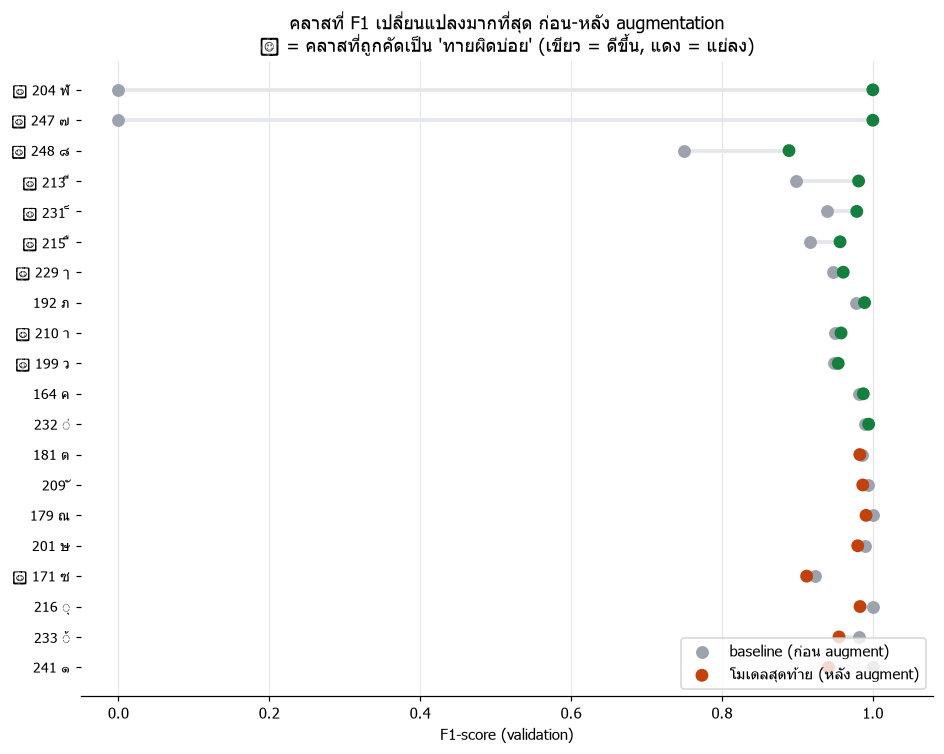

In [24]:
# ----- กราฟ dumbbell: คลาสที่เปลี่ยนแปลงมากที่สุด -----
cmp_df["delta_f1"] = cmp_df["f1-score_final"] - cmp_df["f1-score_baseline"]
changed = pd.concat([cmp_df.nlargest(12, "delta_f1"), cmp_df.nsmallest(8, "delta_f1")])
changed = changed.sort_values("delta_f1")
y = np.arange(len(changed))

fig, ax = plt.subplots(figsize=(10, 7.5))
for yi, (b, f) in enumerate(zip(changed["f1-score_baseline"], changed["f1-score_final"])):
    ax.plot([b, f], [yi, yi], color=GRID, linewidth=2.5, zorder=1)
ax.scatter(changed["f1-score_baseline"], y, s=55, color=GREY, zorder=2, label="baseline (ก่อน augment)")
ax.scatter(changed["f1-score_final"], y, s=55,
           color=np.where(changed["delta_f1"] >= 0, GREEN, RED), zorder=3,
           label="โมเดลสุดท้าย (หลัง augment)")
ax.set_yticks(y)
ax.set_yticklabels([f"{'★ ' if w else '   '}{lab}" for lab, w in
                    zip(changed["label"], changed["was_weak"])], fontsize=9)
ax.set_xlim(-0.05, 1.08)
ax.set_xlabel("F1-score (validation)")
ax.set_title("คลาสที่ F1 เปลี่ยนแปลงมากที่สุด ก่อน-หลัง augmentation\n"
             "★ = คลาสที่ถูกคัดเป็น 'ทายผิดบ่อย' (เขียว = ดีขึ้น, แดง = แย่ลง)")
ax.legend(frameon=True, loc="lower right")
tidy(ax, grid_axis="x")
ax.spines["left"].set_visible(False)
plt.show()

In [25]:
# ----- คู่คลาสที่โมเดลยังสับสนมากที่สุด -----
pairs = read_csv("05_top_confused_pairs_val.csv", dtype={"true_class": str, "pred_class": str})
table = pd.DataFrame(
    {
        "คลาสจริง": [f"{r.true_class} {r.true_char}" for r in pairs.itertuples()],
        "ทำนายเป็น": [f"{r.pred_class} {r.pred_char}" for r in pairs.itertuples()],
        "จำนวนครั้ง": pairs["count"],
        "% ของคลาสจริง": pairs["pct_of_true_class"],
        "ภาพในคลาสจริง": pairs["true_support"],
    }
)
print("10 คู่ที่โมเดลสับสนมากที่สุดบน validation")
print(table.to_string(index=False))
print()
print("ทุกคู่เป็นอักขระที่รูปร่างใกล้กันจริงในลายมือคนไทย เช่น ๅ กับ า ต่างกันแค่")
print("ความสูงของหัว และ ว กับ า ต่างกันแค่หางที่ม้วนเข้า — ไม่ใช่ความสับสนแบบสุ่ม")

10 คู่ที่โมเดลสับสนมากที่สุดบน validation
คลาสจริง ทำนายเป็น  จำนวนครั้ง  % ของคลาสจริง  ภาพในคลาสจริง
   229 ๅ     210 า          23           5.24            439
   199 ว     210 า          14           4.27            328
   210 า     199 ว          13           1.36            955
   210 า     229 ๅ          11           1.15            955
   233 ้     209 ั          10           5.21            192
   227 ใ     210 า           7           3.40            206
   180 ด     181 ต           7           1.82            385
   170 ช     171 ซ           6           3.12            192
   209 ั     233 ้           6           0.77            783
   171 ซ     170 ช           4           7.14             56

ทุกคู่เป็นอักขระที่รูปร่างใกล้กันจริงในลายมือคนไทย เช่น ๅ กับ า ต่างกันแค่
ความสูงของหัว และ ว กับ า ต่างกันแค่หางที่ม้วนเข้า — ไม่ใช่ความสับสนแบบสุ่ม


<a id="6"></a>
## 6. ผลบนชุด Test 5%

ชุดนี้ถูกกันออกตั้งแต่ขั้นตอนแรกและ **ไม่เคยถูกใช้เทรน ไม่เคยถูก augment
และไม่เคยถูกใช้เลือก checkpoint** จึงเป็นตัวเลขที่ประเมินความสามารถของโมเดล
กับข้อมูลที่ไม่เคยเห็นได้อย่างตรงไปตรงมา

In [26]:
test_metrics = read_json("06_test_metrics.json")
test_per_class = read_csv("06_test_classification_report.csv", dtype={"class_id": str})

print(f"ชุด test 5% — {test_metrics['n_images']:,} ภาพ")
print("=" * 72)
print(f"Accuracy          = {test_metrics['accuracy']:.4f}")
print(f"Macro F1          = {test_metrics['macro_f1']:.4f}")
print(f"Weighted F1       = {test_metrics['weighted_f1']:.4f}")
print(f"Balanced accuracy = {test_metrics['balanced_accuracy']:.4f}")
print(f"Top-5 accuracy    = {test_metrics['top5_accuracy']:.4f}")
print("=" * 72)

# เทียบ validation กับ test
compare = pd.DataFrame(
    {
        "Validation": [val_metrics["accuracy"], val_metrics["macro_f1"],
                       val_metrics["weighted_f1"], val_metrics["top5_accuracy"]],
        "Test 5%": [test_metrics["accuracy"], test_metrics["macro_f1"],
                    test_metrics["weighted_f1"], test_metrics["top5_accuracy"]],
    },
    index=["Accuracy", "Macro F1", "Weighted F1", "Top-5 accuracy"],
).round(4)
compare["ส่วนต่าง"] = (compare["Test 5%"] - compare["Validation"]).round(4)
print()
print(compare.to_string())
print()
print("ตัวเลขบน test ต่ำกว่า validation เพียงเล็กน้อย (macro F1 ต่างกัน 0.013)")
print("แสดงว่าโมเดล generalize ได้จริง ไม่ได้ overfit ไปกับ validation ที่ใช้เลือก checkpoint")

ชุด test 5% — 3,136 ภาพ
Accuracy          = 0.9837
Macro F1          = 0.9455
Weighted F1       = 0.9835
Balanced accuracy = 0.9707
Top-5 accuracy    = 0.9990

                Validation  Test 5%  ส่วนต่าง
Accuracy            0.9859   0.9837   -0.0022
Macro F1            0.9584   0.9455   -0.0129
Weighted F1         0.9859   0.9835   -0.0024
Top-5 accuracy      0.9985   0.9990    0.0005

ตัวเลขบน test ต่ำกว่า validation เพียงเล็กน้อย (macro F1 ต่างกัน 0.013)
แสดงว่าโมเดล generalize ได้จริง ไม่ได้ overfit ไปกับ validation ที่ใช้เลือก checkpoint


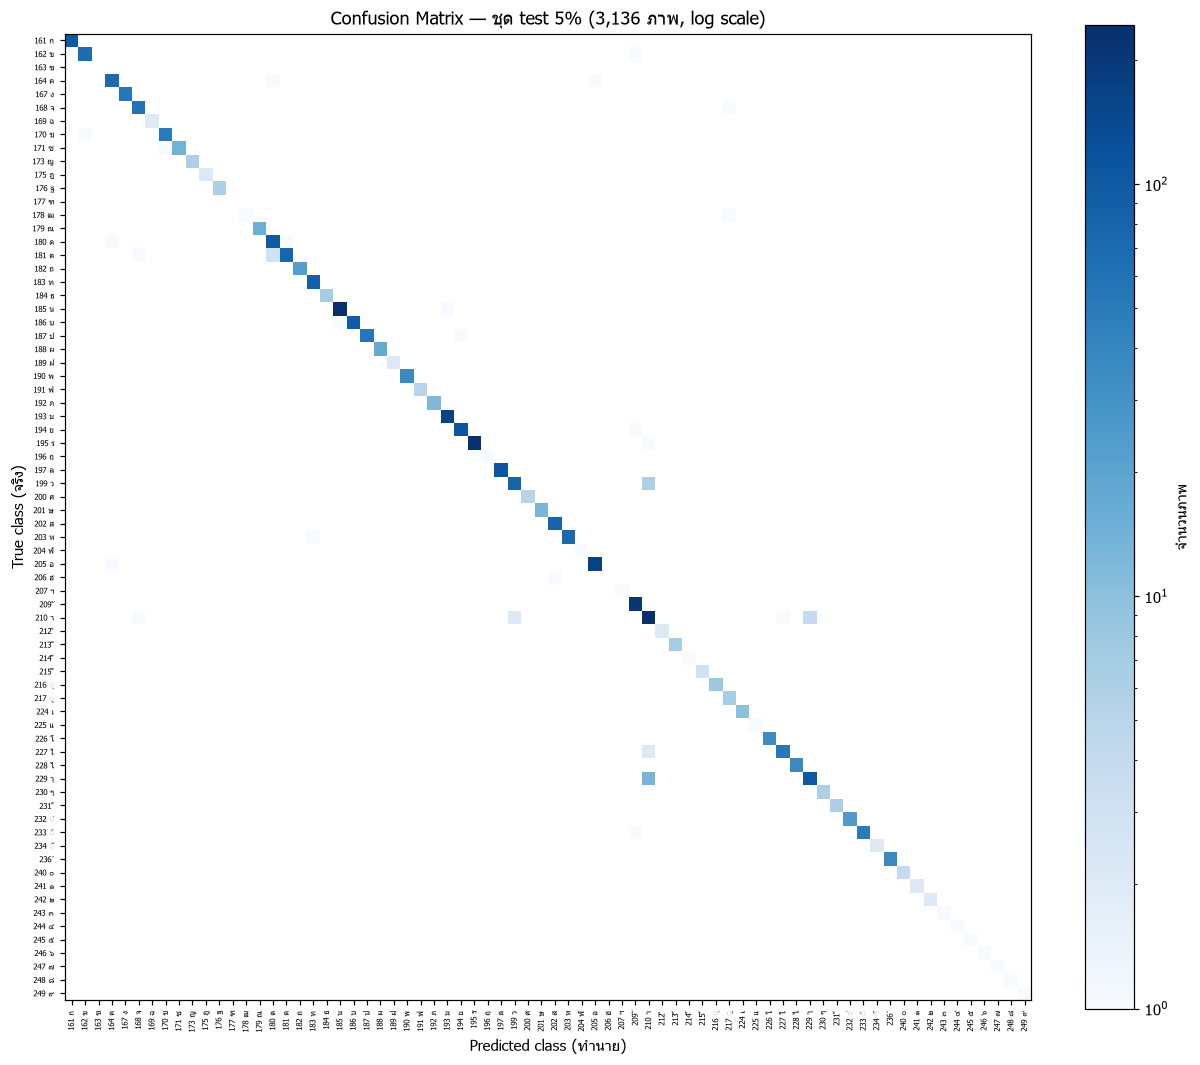

ทายถูก 3,085 / 3,136 ภาพ  (ทายผิด 51 ภาพ)


In [27]:
# ----- Confusion Matrix ของชุด test -----
cm_test = read_csv("06_test_confusion_matrix.csv", index_col=0).to_numpy()
ticks_test = list(read_csv("06_test_confusion_matrix.csv", index_col=0).index)

fig, ax = plt.subplots(figsize=(11, 10))
masked_t = np.ma.masked_where(cm_test == 0, cm_test)
im = ax.imshow(masked_t, cmap="Blues", norm=LogNorm(vmin=1, vmax=max(2, cm_test.max())))
ax.set_xticks(range(len(ticks_test)))
ax.set_yticks(range(len(ticks_test)))
ax.set_xticklabels(ticks_test, rotation=90, fontsize=5)
ax.set_yticklabels(ticks_test, fontsize=5)
ax.set_xlabel("Predicted class (ทำนาย)")
ax.set_ylabel("True class (จริง)")
ax.set_title(f"Confusion Matrix — ชุด test 5% ({cm_test.sum():,} ภาพ, log scale)")
fig.colorbar(im, ax=ax, fraction=0.046, label="จำนวนภาพ")
plt.tight_layout()
plt.show()

correct = int(np.trace(cm_test))
print(f"ทายถูก {correct:,} / {cm_test.sum():,} ภาพ  (ทายผิด {cm_test.sum() - correct} ภาพ)")

In [28]:
# ----- ภาพที่ทายผิดในชุด test: ผิดเป็นคู่ไหนบ้าง -----
wrong_pairs = read_csv("06_test_top_confused_pairs.csv", dtype={"true_class": str, "pred_class": str})
table = pd.DataFrame(
    {
        "คลาสจริง": [f"{r.true_class} {r.true_char}" for r in wrong_pairs.itertuples()],
        "ทำนายเป็น": [f"{r.pred_class} {r.pred_char}" for r in wrong_pairs.itertuples()],
        "จำนวนภาพ": wrong_pairs["count"],
        "% ของคลาสจริง": wrong_pairs["pct_of_true_class"],
    }
)
print("คู่ที่ทายผิดบ่อยที่สุดในชุด test")
print(table.to_string(index=False))

test_measured = test_per_class[test_per_class["support"] > 0]
print()
print("10 คลาสที่ F1 ต่ำสุดในชุด test")
print(test_measured.nsmallest(10, "f1-score")[
    ["label", "precision", "recall", "f1-score", "support"]
].to_string(index=False))

คู่ที่ทายผิดบ่อยที่สุดในชุด test
คลาสจริง ทำนายเป็น  จำนวนภาพ  % ของคลาสจริง
   229 ๅ     210 า        13          11.21
   199 ว     210 า         6           6.98
   210 า     229 ๅ         4           1.59
   181 ต     180 ด         3           3.61
   227 ใ     210 า         2           3.70
   210 า     199 ว         2           0.80
   170 ช     162 ข         1           1.96
   194 ย     209 ั         1           0.91
   164 ค     180 ด         1           1.39
   181 ต     168 จ         1           1.20

10 คลาสที่ F1 ต่ำสุดในชุด test
 label  precision   recall  f1-score  support
 206 ฮ   0.000000 0.000000  0.000000        1
 178 ฒ   1.000000 0.500000  0.666667        2
217 ◌ู   0.777778 1.000000  0.875000        7
 229 ๅ   0.962617 0.887931  0.923767      116
 210 า   0.916981 0.968127  0.941860      251
 199 ว   0.975610 0.930233  0.952381       86
 171 ซ   1.000000 0.933333  0.965517       15
 181 ต   0.987500 0.951807  0.969325       83
 180 ด   0.961165 0.980198  0.970588 

In [29]:
# ----- ตัวอย่างไฟล์ผลทำนายรายภาพที่ส่งให้ตรวจ -----
pred = read_csv("06_test_predictions.csv")
print(f"ไฟล์ผลทำนาย: outputs/reports/06_test_predictions.csv  "
      f"({len(pred):,} แถว, {len(pred.columns)} คอลัมน์)")
print(f"คอลัมน์: {', '.join(pred.columns)}")
print()
cols = ["filename", "true_class_id", "true_char", "pred_class_id", "pred_char", "confidence", "correct"]
print("5 แถวแรก")
print(pred[cols].head(5).to_string(index=False))
print()
print("ตัวอย่างภาพที่ทายผิด")
print(pred.loc[~pred["correct"], cols].head(8).to_string(index=False))
print()
print(f"ความเชื่อมั่นเฉลี่ยตอนทายถูก = {pred.loc[pred['correct'], 'confidence'].mean():.4f}")
print(f"ความเชื่อมั่นเฉลี่ยตอนทายผิด = {pred.loc[~pred['correct'], 'confidence'].mean():.4f}")
print("โมเดล 'ไม่มั่นใจ' ตอนที่มันผิดจริง ซึ่งเป็นพฤติกรรมที่ต้องการ — ถ้านำไปใช้งานจริง")
print("สามารถตั้ง threshold ให้ส่งภาพที่ confidence ต่ำไปให้คนตรวจซ้ำได้")

ไฟล์ผลทำนาย: outputs/reports/06_test_predictions.csv  (3,136 แถว, 17 คอลัมน์)
คอลัมน์: filename, filepath, true_class_id, true_char, pred_class_id, pred_char, confidence, correct, top1_class_id, top1_char, top1_prob, top2_class_id, top2_char, top2_prob, top3_class_id, top3_char, top3_prob

5 แถวแรก
          filename  true_class_id true_char  pred_class_id pred_char  confidence  correct
bc_002sg_5_178.jpg            161         ก            161         ก    0.899158     True
 bc_002sg_5_47.jpg            161         ก            161         ก    0.905490     True
bc_002sg_6_106.jpg            161         ก            161         ก    0.914036     True
bc_002sg_6_130.jpg            161         ก            161         ก    0.900320     True
bc_002tg_4_249.jpg            161         ก            161         ก    0.907098     True

ตัวอย่างภาพที่ทายผิด
          filename  true_class_id true_char  pred_class_id pred_char  confidence  correct
be_014sg_4_304.jpg            162         ข     

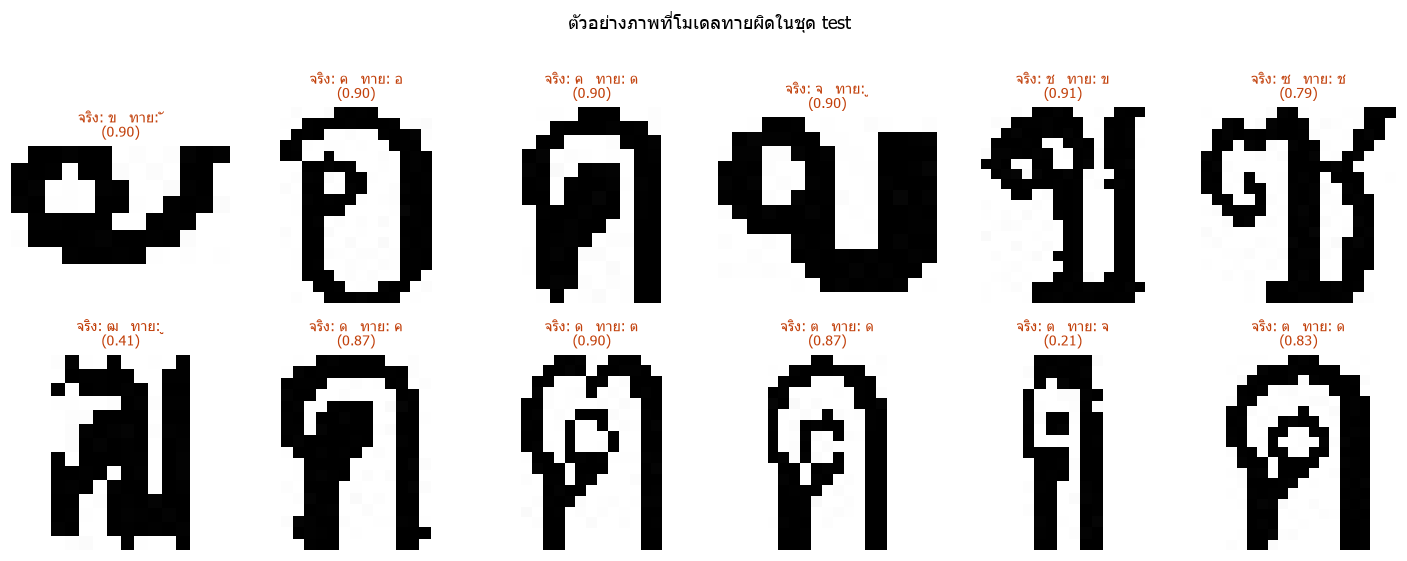

หลายภาพเป็นลายมือที่คนอ่านก็ยังลังเล เช่น ๅ กับ า ที่ต่างกันแค่ความสูงของหัว


In [30]:
# ----- แสดงภาพที่ทายผิดจริง (ต้องมีโฟลเดอร์ dataset) -----
if not HAS_DATASET:
    print("ข้ามเซลล์นี้: ไม่พบโฟลเดอร์ภาพต้นฉบับ")
else:
    from PIL import Image

    wrong = pred.loc[~pred["correct"]].head(12)
    fig, axes = plt.subplots(2, 6, figsize=(13, 5))
    for ax, (_, row) in zip(axes.flatten(), wrong.iterrows()):
        try:
            with Image.open(row["filepath"]) as im:
                ax.imshow(im.convert("RGB"))
        except OSError:
            ax.text(0.5, 0.5, "ไม่พบไฟล์", ha="center", va="center")
        ax.set_title(
            f"จริง: {row['true_char']}   ทาย: {row['pred_char']}\n({row['confidence']:.2f})",
            fontsize=9, color=RED,
        )
        ax.axis("off")
    for ax in axes.flatten()[len(wrong):]:
        ax.axis("off")
    fig.suptitle("ตัวอย่างภาพที่โมเดลทายผิดในชุด test", y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()
    print("หลายภาพเป็นลายมือที่คนอ่านก็ยังลังเล เช่น ๅ กับ า ที่ต่างกันแค่ความสูงของหัว")

<a id="7"></a>
## 7. สรุปและข้อจำกัด

### สิ่งที่ทำ

1. แบ่งข้อมูล 72 คลาส 62,707 ภาพ โดย**กันชุด test 5% ออกก่อนเป็นอย่างแรก**
   แล้วแบ่งที่เหลือเป็น train/val 80:20 แบบ stratified ล็อกด้วย seed 42
2. เทรน baseline ResNet50 3 epochs บนข้อมูลที่ยังไม่ augment เพื่อให้**ข้อมูลบอกเอง**
   ว่าคลาสไหนยาก ได้รายชื่อ 16 คลาสจากเกณฑ์ per-class F1
3. สร้างชุด train ที่ balance ทุกคลาสถึง 3,819 ภาพ (274,968 ภาพต่อ epoch) โดยคลาสที่
   ทายผิดบ่อยใช้ transform เข้มข้นกว่า และไม่ใช้ flip เพราะตัวอักษรไทยมีทิศทาง
4. fine-tune ResNet50 ทั้งโมเดล 10 epochs ด้วย AdamW + CosineAnnealingLR +
   label smoothing 0.1 + mixed precision เลือก best checkpoint ด้วย **macro F1**
5. ประเมินผลด้วย confusion matrix, classification report รายคลาส และเทียบ F1
   ก่อน-หลัง augmentation
6. ทำนายชุด test 5% ที่กันไว้ ได้ **accuracy 0.9837 / macro F1 0.9455**

### ผลที่ได้

| ตัวชี้วัด | Baseline (ไม่ augment) | โมเดลสุดท้าย | ส่วนต่าง |
|---|---|---|---|
| Validation accuracy | 0.9846 | 0.9859 | +0.001 |
| **Validation macro F1** | **0.9273** | **0.9584** | **+0.031** |
| F1 เฉลี่ยของ 14 คลาสที่ทายผิดบ่อย | 0.7922 | 0.9582 | **+0.166** |

ข้อสรุปสำคัญคือ **accuracy แทบไม่ขยับแต่ macro F1 ขึ้นชัดเจน** ซึ่งเป็นภาพที่ถูกต้อง
สำหรับงานที่ข้อมูลไม่สมดุล: ประโยชน์ของ augmentation ไปลงที่คลาสเล็กที่ accuracy
มองไม่เห็น ถ้าวัดด้วย accuracy อย่างเดียวจะสรุปผิดว่า "augmentation แทบไม่ช่วยอะไร"

### ข้อจำกัดที่ต้องระบุ

1. **2 คลาสไม่มีภาพในชุด test** (`163 ฃ`, `177 ฑ`) เพราะทั้งคลาสมีภาพเพียง 1 ภาพ
   ตัวเลขบนชุด test จึงวัดได้ 70 จาก 72 คลาส และคลาสเหล่านี้ก็ไม่มีภาพใน validation
   ด้วย — ความสามารถจริงของโมเดลกับสองคลาสนี้ยังไม่ทราบ
2. **ยังเหลือ overfitting** train F1 อยู่ที่ 0.9998 ขณะที่ val F1 อยู่ 0.958
   ทางที่จะลองต่อ: weight decay สูงกว่า 0.01, MixUp/CutMix, หรือ early stopping
   ที่ epoch 8 ตรง ๆ
3. **ภาพ augment ถูกล็อกด้วย seed จึงคงที่ทุก epoch** ซึ่งทำให้ reproduce ได้ 100%
   แต่แลกมากับความหลากหลายที่น้อยกว่าการสุ่มใหม่ทุก epoch (มีตัวเลือก
   `--fresh-aug-each-epoch` ให้เปรียบเทียบ)
4. **คู่ที่ยังสับสนเป็นคู่ที่รูปร่างใกล้กันจริง** (`ๅ`/`า`, `ว`/`า`, `ต`/`ด`)
   ซึ่งอาจต้องใช้ความละเอียดภาพที่สูงกว่า 224×224 หรือเทคนิคที่เน้นรายละเอียด
   เชิงโครงสร้างของเส้น จึงจะแยกได้ดีขึ้น

### ไฟล์ที่เกี่ยวข้อง

| ไฟล์ | เนื้อหา |
|---|---|
| `run_step1_explore.py` … `run_step6_test_inference.py` | โค้ดแต่ละขั้นที่รันจริง |
| `torch_pipeline/` | โมดูล: config, data, augment, model, reporting, viz |
| `RESULTS.md` | รายงานผลแบบเต็ม สร้างอัตโนมัติจากไฟล์ผลลัพธ์ |
| `README.md` | คู่มือการรันและบันทึกการตัดสินใจทางเทคนิค |
| `outputs/figures/` | กราฟทั้งหมด 18 ใบ ความละเอียด dpi 300 |
| `outputs/reports/` | ตาราง CSV/JSON ของทุกผลลัพธ์ |